In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm 
import scipy.stats as stats
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
from scipy.stats import skew 
from scipy.stats import kurtosis
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import FuncFormatter


In [2]:
fpath = 'C:\\Users\\gg00642\\OneDrive - University of Surrey\\Desktop\\Actigraphy Sara'
#fpath = 'C:\\Users\\gianl\\Desktop\\Actigraphy Sara'

In [3]:
df = pd.read_excel(fpath + '\\10.0_database_variables.xlsx', sheet_name = 'database_2022_2024')

In [4]:
# Rename columns
df = df.rename(columns={'location(ita=0,uk=1)': 'location', 'week(1=free days)': 'weekday_type'})

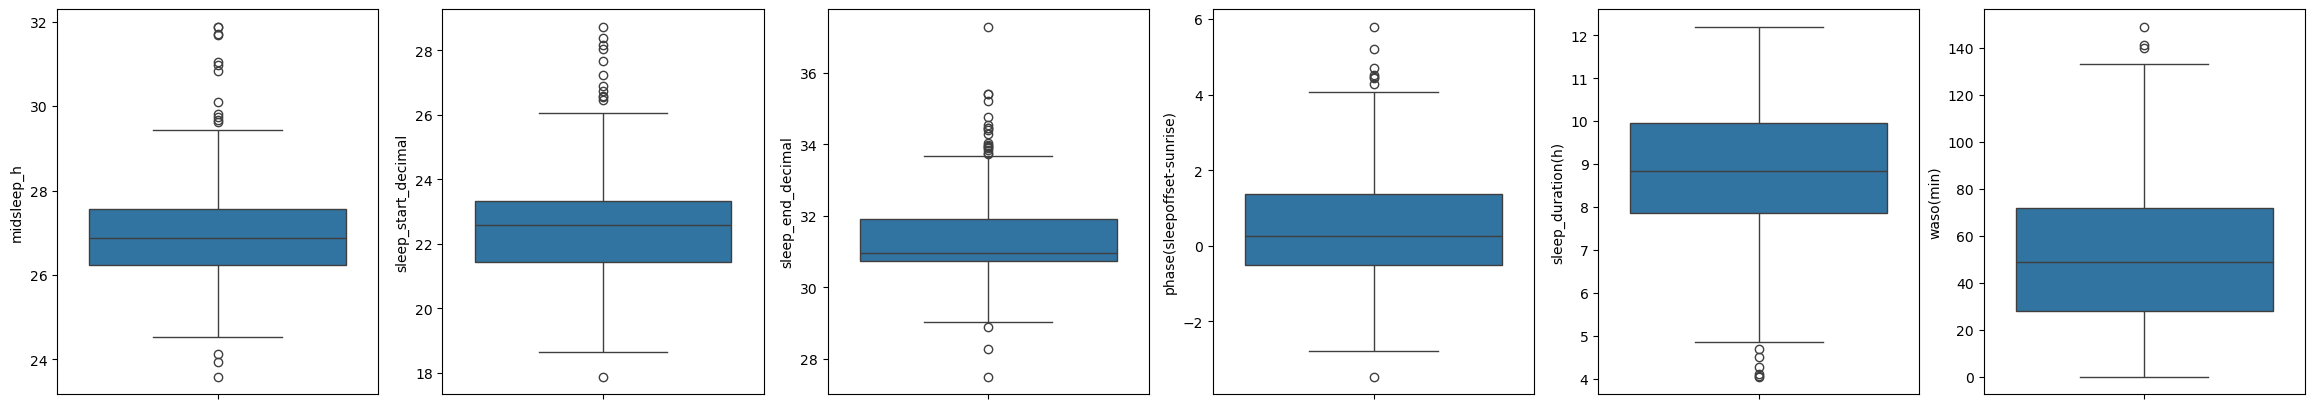

In [5]:
fig, ax = plt.subplots(1, 6, figsize=(29, 5))
sns.boxplot(data=df['midsleep_h'], ax=ax[0])
sns.boxplot(data=df['sleep_start_decimal'], ax=ax[1])
sns.boxplot(data=df['sleep_end_decimal'], ax=ax[2])
sns.boxplot(data=df['phase(sleepoffset-sunrise)'], ax=ax[3])
sns.boxplot(data=df['sleep_duration(h)'], ax=ax[4])
sns.boxplot(data=df['waso(min)'], ax=ax[5])

plt.show()

In [6]:
# define the start date
start_date = pd.to_datetime('2022-02-01')

In [7]:
# function to count the week of the year from the start date 2022-02-01
def calculate_week_of_year(start_datetime): return (start_datetime - start_date).days // 7 + 5

# apply the function to calculate the week of the year
df['week_of_year'] = df['date'].apply(calculate_week_of_year)

In [8]:
# adjust 'week of the year' to start from 0
df['week_of_year'] = df['week_of_year'] - 37

In [9]:
# rename the location column as 0=ITA, 1=UK
df['location'] = df['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df['weekday_type'] = df['weekday_type'].map({0: 'work days', 1: 'free days'})

In [10]:
# calculate the sleep duration for work days and free days
df['sleep_duration(h)'] = df['sleep_duration(h)'].astype(float)
df['sleep_duration_work_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'work days')
df['sleep_duration_free_days'] = df['sleep_duration(h)'] * (df['weekday_type'] == 'free days')

In [11]:
# filtered the midpoints by type of day of the week
# new dataframe with only the midpoints of the work days/free days
df_workdays = df[df['weekday_type'] == 'work days']
df_freedays = df[df['weekday_type'] == 'free days']

In [12]:
# create a new df for weekly jetlag analysis
data_jetlag = df 

In [13]:
# calculate the mean midpoint for each location, week and weekday
weekly_means_jetlag = data_jetlag.groupby(['location', 'week_of_year', 'weekday_type'])['midsleep_h'].mean().unstack()

In [14]:
# calculate the jet lag 
weekly_means_jetlag['jet lag'] = weekly_means_jetlag['free days'] - weekly_means_jetlag['work days']

In [15]:
# add a column with the location to the weekly_means_jetlag_UTC
weekly_means_jetlag['location'] = weekly_means_jetlag.index.get_level_values(0)

In [16]:
# rename columns
df = df.rename(columns={'sleep_duration(h)': 'sleep_duration'})
df = df.rename(columns={'phase(sleepoffset-sunrise)': 'phase'})
df = df.rename(columns={'waso(min)': 'waso'})
df = df.rename(columns={'DST(0=ST)': 'DST_1'})

In [17]:
# dictionary with the season dates
seasons = {'Winter': [(12, 21), (3, 20)], 'Spring': [(3, 21), (6, 20)], 'Summer': [(6, 21), (9, 22)], 'Autumn': [(9, 23), (12, 20)]}

df['date'] = pd.to_datetime(df['date'])

In [18]:
# Function to get the season from the date
def get_season(date):
    month, day = date.month, date.day
    for season, ((start_month, start_day), (end_month, end_day)) in seasons.items():
        if (month == start_month and day >= start_day) or (month == end_month and day <= end_day):
            return season
        elif start_month < month < end_month:
            return season
    return 'Winter'  # for dates before 21st December and after 20th December

In [19]:
# Applying the function to create a season column
df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)
df.loc[:, 'season'] = df['date'].apply(get_season)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2634099026.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[:, 'season'] = df_workdays['date'].apply(get_season)
C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2634099026.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[:, 'season'] = df_freedays['date'].apply(get_season)


In [20]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df['photoperiod'] = np.where(df['location'] == 'UK', df['photoperiod (h, UK)'], df['photoperiod (h, ITA)'])

In [21]:
# add a column with the photoperiod for the UK and ITA
df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)'] 
df_workdays.loc[df_workdays['location'] == 'ITA', 'photoperiod'] = df_workdays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\1608732957.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_workdays.loc[df_workdays['location'] == 'UK', 'photoperiod'] = df_workdays['photoperiod (h, UK)']


In [22]:
# add the photoperiod column to the df_freedays
df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']
df_freedays.loc[df_freedays['location'] == 'ITA', 'photoperiod'] = df_freedays['photoperiod (h, ITA)']

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2381324628.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_freedays.loc[df_freedays['location'] == 'UK', 'photoperiod'] = df_freedays['photoperiod (h, UK)']


In [23]:
# descpriptive statistics
all_descriptive = df.describe()
all_descriptive = all_descriptive.transpose()

In [24]:
# add the index as a column
all_descriptive['variable'] = all_descriptive.index 

In [25]:
#reset the index
all_descriptive = all_descriptive.reset_index(drop=True)

In [26]:
all_descriptive.to_excel(fpath + '\\all_descriptive.xlsx')

In [27]:
#descriptive for workdays and freedays
workdays_descriptive = df_workdays.describe()
workdays_descriptive = workdays_descriptive.transpose()

# add the index as a column
workdays_descriptive['variable'] = workdays_descriptive.index

#reset the index
workdays_descriptive = workdays_descriptive.reset_index(drop=True)

In [28]:
# save the descriptive statistics for freedays
freedays_descriptive = df_freedays.describe()
freedays_descriptive = freedays_descriptive.transpose()

# add the index as a column
freedays_descriptive['variable'] = freedays_descriptive.index

#reset the index
freedays_descriptive = freedays_descriptive.reset_index(drop=True)

In [29]:
# descpriptive statistics for ITA
descriptive_ita = df[df['location'] == 'ITA'].describe()
descriptive_ita = descriptive_ita.transpose()
descriptive_ita['variable'] = descriptive_ita.index 

In [30]:
# descpriptive statistics for UK
descriptive_uk = df[df['location'] == 'UK'].describe()
descriptive_uk = descriptive_uk.transpose()
descriptive_uk['variable'] = descriptive_uk.index 

In [31]:
# % of time spent in each location
count_location = df['location'].value_counts(normalize=True) * 100

In [32]:
count_location

location
ITA    58.258258
UK     41.741742
Name: proportion, dtype: float64

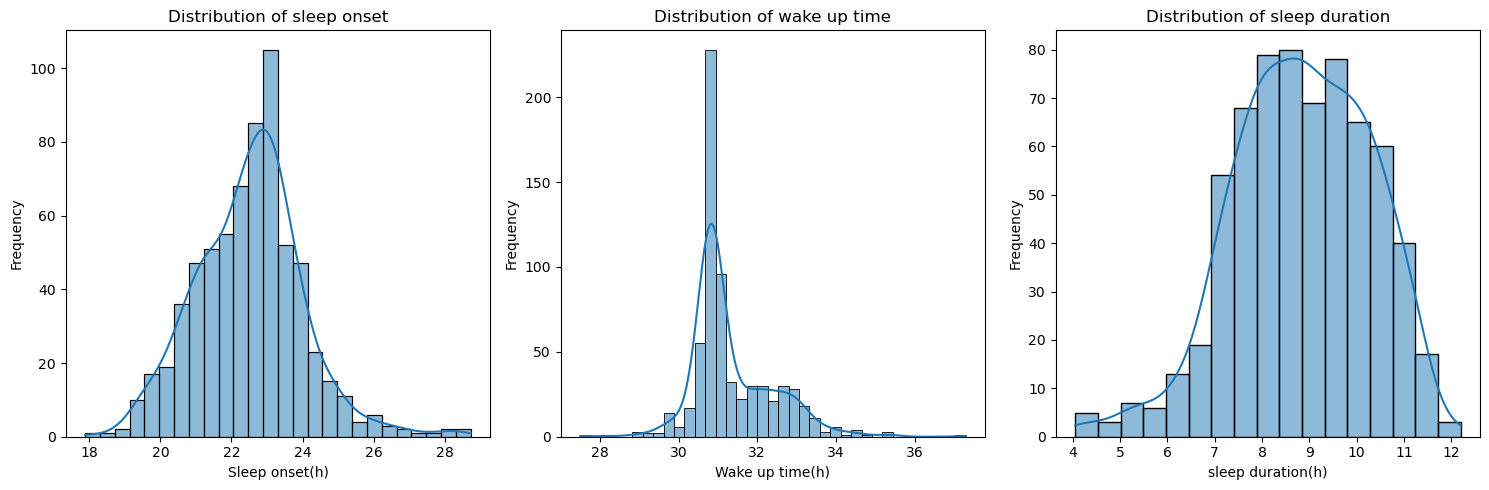

In [33]:
# distribution of the midpoint, sleep onset, sleep offset, and sleep duration
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['sleep_start_decimal'].dropna(), kde=True)
plt.title("Distribution of sleep onset")
plt.xlabel("Sleep onset(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(df['sleep_end_decimal'].dropna(), kde=True)
plt.title("Distribution of wake up time")
plt.xlabel("Wake up time(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(df['sleep_duration'].dropna(), kde=True)
plt.title("Distribution of sleep duration")
plt.xlabel("sleep duration(h)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

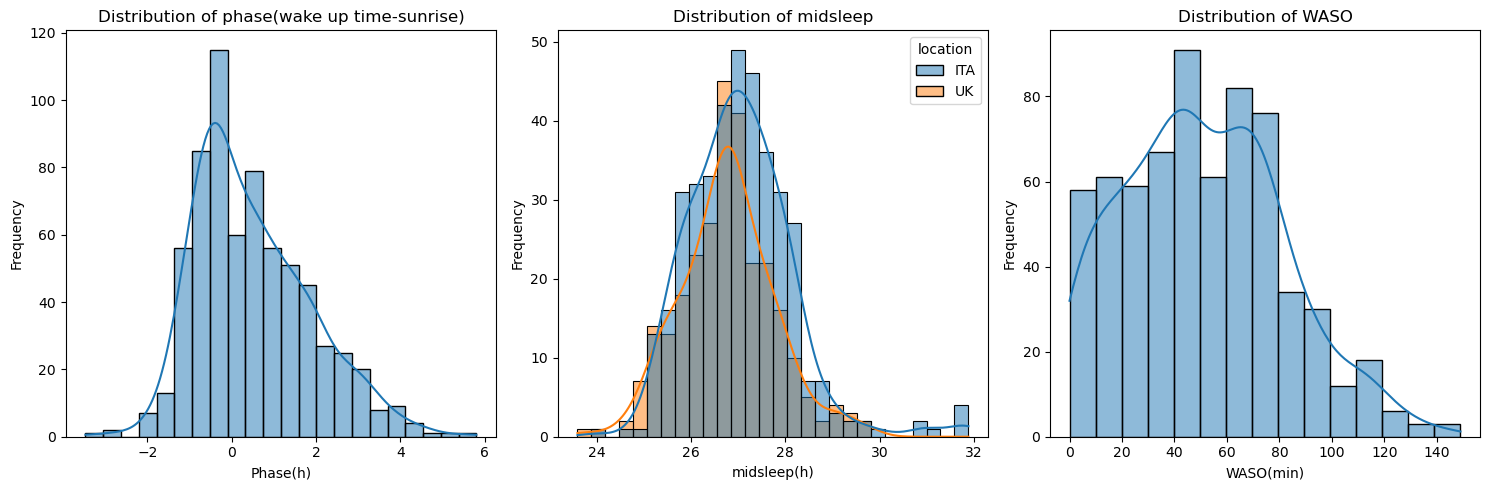

In [34]:
# distribution of phase and midpoint of sleep
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
sns.histplot(df['phase'].dropna(), kde=True)
plt.title("Distribution of phase(wake up time-sunrise)")
plt.xlabel("Phase(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
sns.histplot(data=df, x='midsleep_h', kde=True, hue='location')
plt.title("Distribution of midsleep")
plt.xlabel("midsleep(h)")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
sns.histplot(data=df, x='waso', kde=True)
plt.title("Distribution of WASO")
plt.xlabel("WASO(min)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

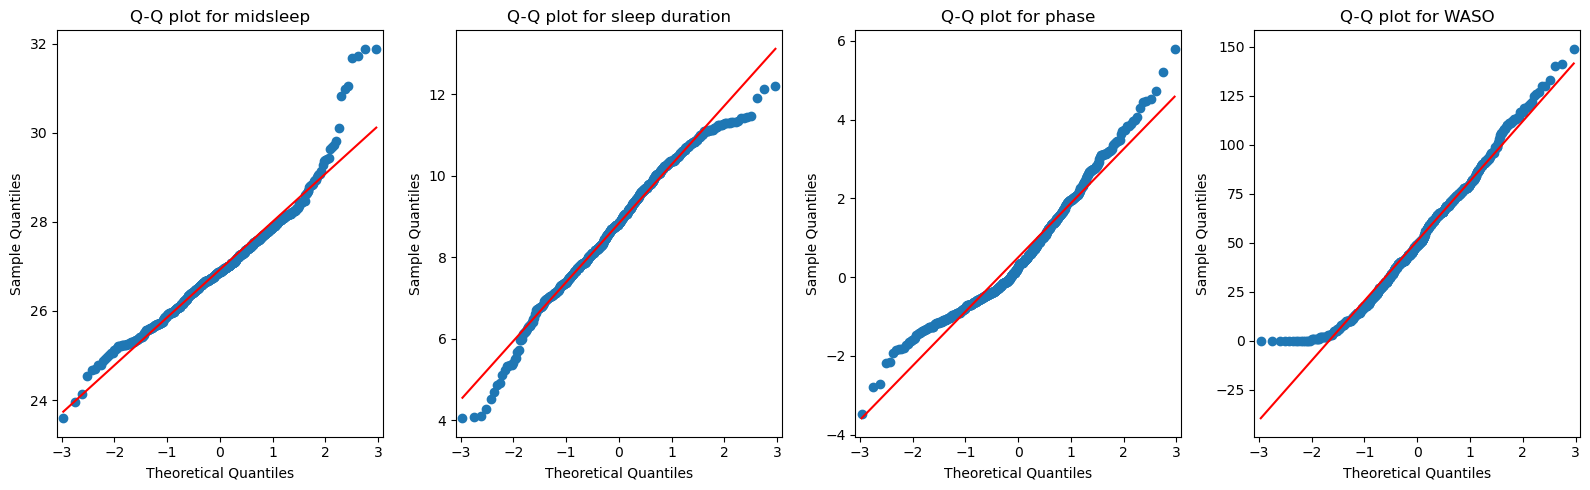

In [35]:
# Test normality by Q-Q plot
fig, ax = plt.subplots(1, 4, figsize=(16, 5))

sm.qqplot(df['midsleep_h'].dropna(), line='s', ax=ax[0])
ax[0].set_title('Q-Q plot for midsleep')

sm.qqplot(df['sleep_duration'].dropna(), line='s', ax=ax[1])
ax[1].set_title('Q-Q plot for sleep duration')

sm.qqplot(df['phase'].dropna(), line='s', ax=ax[2])
ax[2].set_title('Q-Q plot for phase')

sm.qqplot(df['waso'].dropna(), line='s', ax=ax[3])
ax[3].set_title('Q-Q plot for WASO')

plt.tight_layout()
plt.show()


In [36]:
# test normality of the data using Shapiro-Wilk test 
# Null hipotesis(H0): data is normally distributed
shapiro_test_sleep_duration = stats.shapiro(df['sleep_duration'])
shapiro_test_midsleep = stats.shapiro(df['midsleep_h'])
shapiro_test_sleep_start = stats.shapiro(df['sleep_start_decimal'])
shapiro_test_sleep_end = stats.shapiro(df['sleep_end_decimal'])
shapiro_test_phase = stats.shapiro(df['phase'])
shapiro_test_waso = stats.shapiro(df['waso'].dropna())

In [37]:
shapiro_results_x = pd.DataFrame({
    'Variable': ['sleep_duration', 'midsleep_h', 'sleep_start_decimal', 'sleep_end_decimal', 'phase(sleepoffset-sunrise)', 'waso(min)'],
    'Shapiro-Wilk test': [shapiro_test_sleep_duration, shapiro_test_midsleep, shapiro_test_sleep_start, shapiro_test_sleep_end, shapiro_test_phase, shapiro_test_waso]
})

In [38]:
shapiro_results_x

,Variable,Shapiro-Wilk test
0,sleep_duration,"(0.9848850022350736, 2.21940674272492e-06)"
1,midsleep_h,"(0.9624510194180114, 5.0539796981387916e-12)"
2,sleep_start_decimal,"(0.9821700924977277, 2.9902087013896615e-07)"
3,sleep_end_decimal,"(0.881574446037927, 3.9483574809182507e-22)"
4,phase(sleepoffset-sunrise),"(0.9626282705791135, 5.474629945466521e-12)"
5,waso(min),"(0.9795681653958959, 5.630409812834638e-08)"


In [39]:
# Function to convert hours to hh:mm format
def hours_to_hhmm(x, pos):
    hours = int(x)
    minutes = int((x - hours) * 60)
    return f'{hours:02d}:{minutes:02d}'

__Sleep-wake pattern between workdays and free days__

In [40]:
# descriptive statistics by location
df_grouped_weekdaytype = df.groupby('weekday_type').describe()

In [41]:
# compare variables between workdays and free days
# compare the variables between ITA and UK
ttest_midsleep_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['midsleep_h'], df[df['weekday_type'] == 'free days']['midsleep_h'])
ttest_duration_daytype = stats.ttest_ind(df[df['weekday_type'] == 'work days']['sleep_duration'], df[df['weekday_type'] == 'free days']['sleep_duration'])

utest_phase_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['phase'], df[df['weekday_type'] == 'free days']['phase'])
utest_start_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_start_decimal'], df[df['weekday_type'] == 'free days']['sleep_start_decimal'])
utest_end_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['sleep_end_decimal'], df[df['weekday_type'] == 'free days']['sleep_end_decimal'])
utest_waso_daytype = stats.mannwhitneyu(df[df['weekday_type'] == 'work days']['waso'].dropna(), df[df['weekday_type'] == 'free days']['waso'].dropna())

In [42]:
# print the results
print('T test results by day type')
print('T test midsleep:', ttest_midsleep_daytype)
print('T test duration:', ttest_duration_daytype)
print('U test results by day type')
print('U test phase:', utest_phase_daytype)
print('U test start:', utest_start_daytype)
print('U test end:', utest_end_daytype)
print('U test waso:', utest_waso_daytype)


T test results by day type
T test midsleep: TtestResult(statistic=-7.615055816859831, pvalue=9.093858113996217e-14, df=664.0)
T test duration: TtestResult(statistic=-3.1753579215872594, pvalue=0.001565754050608145, df=664.0)
U test results by day type
U test phase: MannwhitneyuResult(statistic=27894.0, pvalue=5.60152765531563e-14)
U test start: MannwhitneyuResult(statistic=35393.5, pvalue=3.316581048701907e-05)
U test end: MannwhitneyuResult(statistic=21926.0, pvalue=2.0579832845312918e-24)
U test waso: MannwhitneyuResult(statistic=35729.0, pvalue=0.0002669390867751625)


__Sleep-wake pattern between Uk and Italy__

In [43]:
# descriptive statistics by location
df_grouped_location = df.groupby('location').describe()
df_grouped_location = df_grouped_location.transpose()

In [44]:
# chi square for actual wake (%) between uk and ita
contingency_table = pd.crosstab(df['location'], df['actual_wake(%)'])
chi2, p, dof, expected = stats.chi2_contingency(contingency_table)

# print the results
print('Chi square test for actual wake between UK and ITA')
print('Chi square:', chi2)
print('p-value:', p)

Chi square test for actual wake between UK and ITA
Chi square: 650.1924937999154
p-value: 0.4683776231285227


In [45]:
# compare the variables between ITA and UK
ttest_midsleep_all_loc = stats.ttest_ind(df[df['location'] == 'ITA']['midsleep_h'], df[df['location'] == 'UK']['midsleep_h'])
ttest_duration_loc = stats.ttest_ind(df[df['location'] == 'ITA']['sleep_duration'], df[df['location'] == 'UK']['sleep_duration'])

utest_phase_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['phase'], df[df['location'] == 'UK']['phase'])
utest_start_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_start_decimal'], df[df['location'] == 'UK']['sleep_start_decimal'])
utest_end_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['sleep_end_decimal'], df[df['location'] == 'UK']['sleep_end_decimal'])
utest_waso_loc = stats.mannwhitneyu(df[df['location'] == 'ITA']['waso'].dropna(), df[df['location'] == 'UK']['waso'].dropna())

In [46]:
# print the results
print('T test results by location')
print('Midsleep_all:', ttest_midsleep_all_loc)
print('Sleep_duration:', ttest_duration_loc)
print('U test results by location')
print('Sleep_onset:', utest_start_loc)
print('Sleep_offset:', utest_end_loc)
print('Phase:', utest_phase_loc)
print('WASO:', utest_waso_loc)

T test results by location
Midsleep_all: TtestResult(statistic=3.1967759199204635, pvalue=0.0014556640965908442, df=664.0)
Sleep_duration: TtestResult(statistic=-0.6826135588013178, pvalue=0.4950891344799263, df=664.0)
U test results by location
Sleep_onset: MannwhitneyuResult(statistic=59760.0, pvalue=0.017313332694237512)
Sleep_offset: MannwhitneyuResult(statistic=62690.0, pvalue=0.0003479759888140954)
Phase: MannwhitneyuResult(statistic=54873.0, pvalue=0.7009016518533244)
WASO: MannwhitneyuResult(statistic=41511.0, pvalue=1.5940348188153738e-06)


In [47]:
# the statistic value in the mannwhitneyu test is the z statistic? 

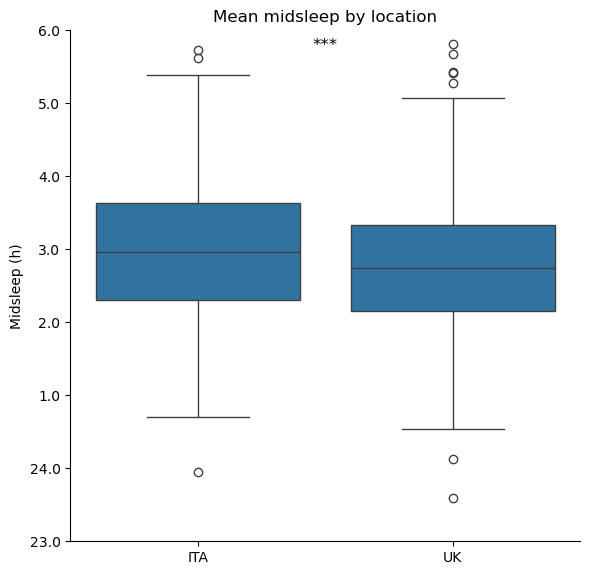

In [48]:
# plot the midpoint of sleep by location
plt.figure(figsize=(6, 6))
sns.boxplot(x='location', y='midsleep_h', data=df)
plt.title('Mean midsleep by location')
plt.suptitle('')  
plt.xlabel('')
plt.ylabel('Midsleep (h)')
plt.ylim(23, 30)
# after 24 reset the y-axis to 1
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
# Format y-axis to hh:mm
#plt.gca().yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5)) # gcd stands for 'get current axis'
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.tight_layout()

plt.show()

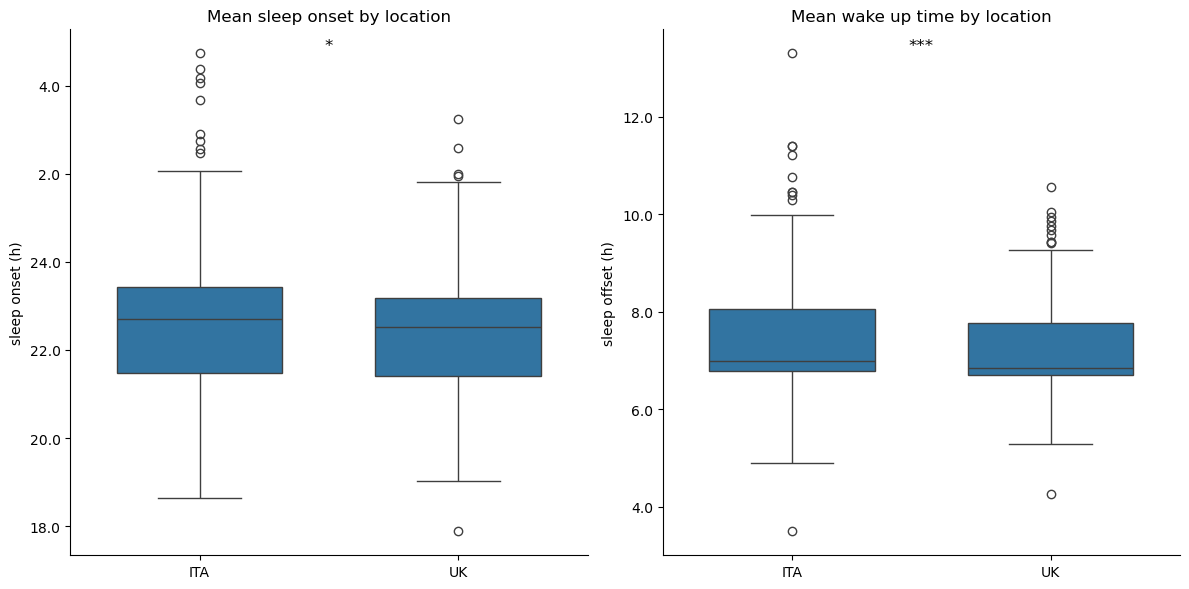

In [49]:
# plot the sleep onset and sleep offset by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='sleep_start_decimal', data=df, gap=0.2)
plt.title('Mean sleep onset by location')
plt.xlabel('')
plt.ylabel('sleep onset (h)')
plt.annotate('*', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.subplot(1, 2, 2)
sns.boxplot(x='location', y='sleep_end_decimal', data=df, gap=0.2)
plt.title('Mean wake up time by location')
plt.xlabel('')
plt.ylabel('sleep offset (h)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12) #add a significance line to the subplot
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
sns.despine()
plt.tight_layout()
plt.show()

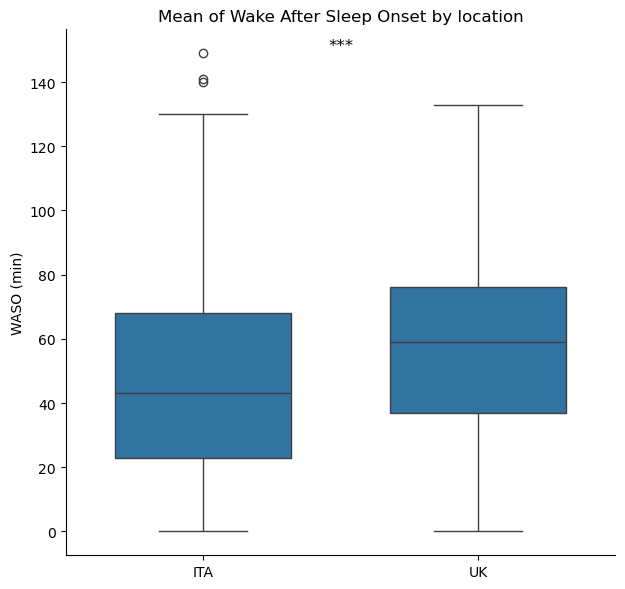

In [50]:
# plot the waso by location
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='location', y='waso', data=df, gap=0.2)
plt.title('Mean of Wake After Sleep Onset by location')
plt.xlabel('')
plt.ylabel('WASO (min)')
plt.annotate('***', xy=(0.5, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
#plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))

sns.despine()
plt.tight_layout()
plt.show()

__Jet lag__

In [51]:
# drop the rows with missing values
jetlag_clean = weekly_means_jetlag['jet lag'].dropna()

In [52]:
# Test normality of the jet lag data using Shapiro-Wilk test 
# H0: data is normally distributed
shapiro_test_jetlag = stats.shapiro(jetlag_clean)

In [53]:
print('Shapiro test result for jet lag:')
print(shapiro_test_jetlag)

Shapiro test result for jet lag:
ShapiroResult(statistic=0.9876125382572299, pvalue=0.4370184776875048)


In [54]:
# test the difference in jet lag between the two locations
ttest_jetlag = stats.ttest_ind(weekly_means_jetlag[weekly_means_jetlag['location'] == 'ITA']['jet lag'].dropna(), 
                               weekly_means_jetlag[weekly_means_jetlag['location'] == 'UK']['jet lag'].dropna())

In [55]:
print('T test result for jet lag by location:')
print(ttest_jetlag)

T test result for jet lag by location:
TtestResult(statistic=-0.744182642873099, pvalue=0.45844414182344906, df=104.0)


__Season and sleep-wake pattern__

In [56]:
# remove NaN values from the columns and create a new dataframe
df1 = df.dropna(subset=['sleep_duration']) 
df2 = df.dropna(subset=['phase'])
df3 = df.dropna(subset=['waso'])

In [57]:
anova_ols_midsleep_season = ols('midsleep_h ~ C(season)', data=df).fit() # generate and fit the regression model
anova_results_midsleep = sm.stats.anova_lm(anova_ols_midsleep_season, typ=3) # fit the ANOVA model and get the results

In [58]:
print('ANOVA Result for midsleep:')
print(anova_results_midsleep)

ANOVA Result for midsleep:
                  sum_sq     df              F    PR(>F)
Intercept  186626.067365    1.0  162360.576817  0.000000
C(season)       7.496111    3.0       2.173817  0.089882
Residual      760.938764  662.0            NaN       NaN


In [59]:
anova_sleep_duration_season = ols('sleep_duration ~ C(season)', data=df1).fit()
anova_results_sleep_duration = sm.stats.anova_lm(anova_sleep_duration_season, typ=3)

print('ANOVA Result for sleep duration:')
print(anova_results_sleep_duration)

ANOVA Result for sleep duration:
                 sum_sq     df            F    PR(>F)
Intercept  18684.482667    1.0  9131.619328  0.000000
C(season)     32.027700    3.0     5.217605  0.001448
Residual    1354.538235  662.0          NaN       NaN


In [60]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df1['sleep_duration'], df1['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
Autumn Spring   0.4642  0.023  0.0453 0.8832   True
Autumn Summer   0.3848 0.0655 -0.0163  0.786  False
Autumn Winter   0.4791 0.0039  0.1168 0.8414   True
Spring Summer  -0.0794  0.974  -0.559 0.4002  False
Spring Winter   0.0149 0.9998 -0.4327 0.4624  False
Summer Winter   0.0943 0.9429 -0.3367 0.5252  False
---------------------------------------------------


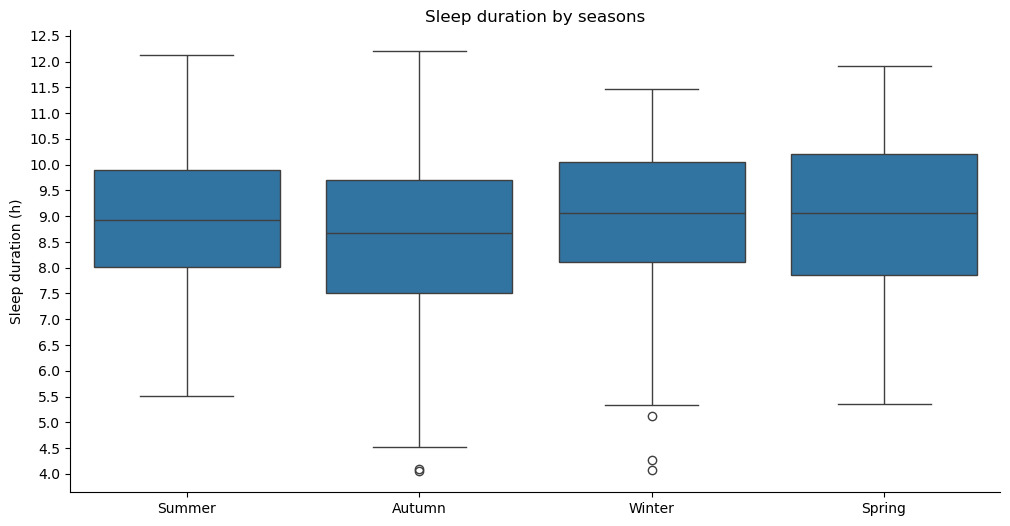

In [61]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_duration', data=df1)
plt.title('Sleep duration by seasons')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black') 
plt.gca().spines['left'].set_color('black')
plt.show()

In [62]:
# perform a Kruskal-Wallis test to compare the phase, sleep end and waso between the seasons
kw_phase_season = stats.kruskal(df2[df2['season'] == 'Winter']['phase'], df2[df2['season'] == 'Spring']['phase'], 
                                df2[df2['season'] == 'Summer']['phase'], df2[df2['season'] == 'Autumn']['phase'])

kw_start_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_start_decimal'], df[df['season'] == 'Spring']['sleep_start_decimal'], 
                              df[df['season'] == 'Summer']['sleep_start_decimal'], df[df['season'] == 'Autumn']['sleep_start_decimal'])

kw_end_season = stats.kruskal(df[df['season'] == 'Winter']['sleep_end_decimal'], df[df['season'] == 'Spring']['sleep_end_decimal'], 
                              df[df['season'] == 'Summer']['sleep_end_decimal'], df[df['season'] == 'Autumn']['sleep_end_decimal'])

kw_waso_season = stats.kruskal(df3[df3['season'] == 'Winter']['waso'], df3[df3['season'] == 'Spring']['waso'], 
                               df3[df3['season'] == 'Summer']['waso'], df3[df3['season'] == 'Autumn']['waso'])

print('Kruskal-Wallis test results for phase:')
print(kw_phase_season)
print('Kruskal-Wallis test results for sleep start:')
print(kw_start_season)
print('Kruskal-Wallis test results for sleep end:')
print(kw_end_season)
print('Kruskal-Wallis test results for waso:')  
print(kw_waso_season)

Kruskal-Wallis test results for phase:
KruskalResult(statistic=239.20430617422772, pvalue=1.4144049850108187e-51)
Kruskal-Wallis test results for sleep start:
KruskalResult(statistic=8.267619534162204, pvalue=0.040792794193028725)
Kruskal-Wallis test results for sleep end:
KruskalResult(statistic=3.5986530047656777, pvalue=0.30819075034843046)
Kruskal-Wallis test results for waso:
KruskalResult(statistic=3.381088116126334, pvalue=0.3365152056949655)


In [63]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df2['phase'], df2['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring   1.6327    0.0   1.301  1.9643   True
Autumn Summer   1.6302    0.0  1.3126  1.9478   True
Autumn Winter  -0.0262 0.9954 -0.3129  0.2606  False
Spring Summer  -0.0025    1.0 -0.3821  0.3772  False
Spring Winter  -1.6588    0.0 -2.0131 -1.3046   True
Summer Winter  -1.6564    0.0 -1.9975 -1.3152   True
----------------------------------------------------


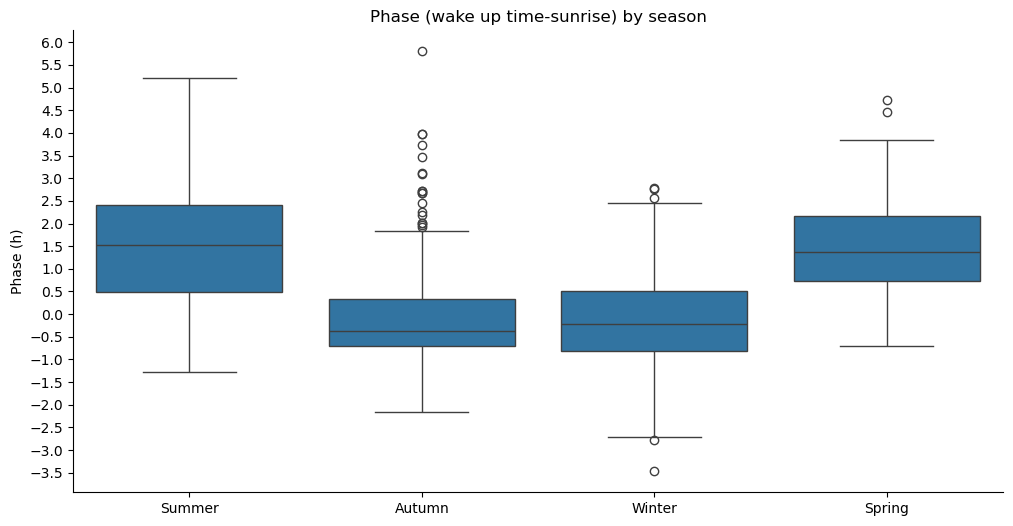

In [64]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

In [65]:
# Post hoc test: perform a Tukey HSD test to compare the means
tukey_results_season = pairwise_tukeyhsd(df['sleep_start_decimal'], df['season'])
print(tukey_results_season)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
Autumn Spring  -0.5029 0.0171 -0.9414 -0.0645   True
Autumn Summer  -0.3497 0.1401 -0.7696  0.0702  False
Autumn Winter  -0.4399 0.0154  -0.819 -0.0607   True
Spring Summer   0.1533 0.8607 -0.3487  0.6552  False
Spring Winter   0.0631 0.9857 -0.4053  0.5315  False
Summer Winter  -0.0902 0.9555 -0.5412  0.3609  False
----------------------------------------------------


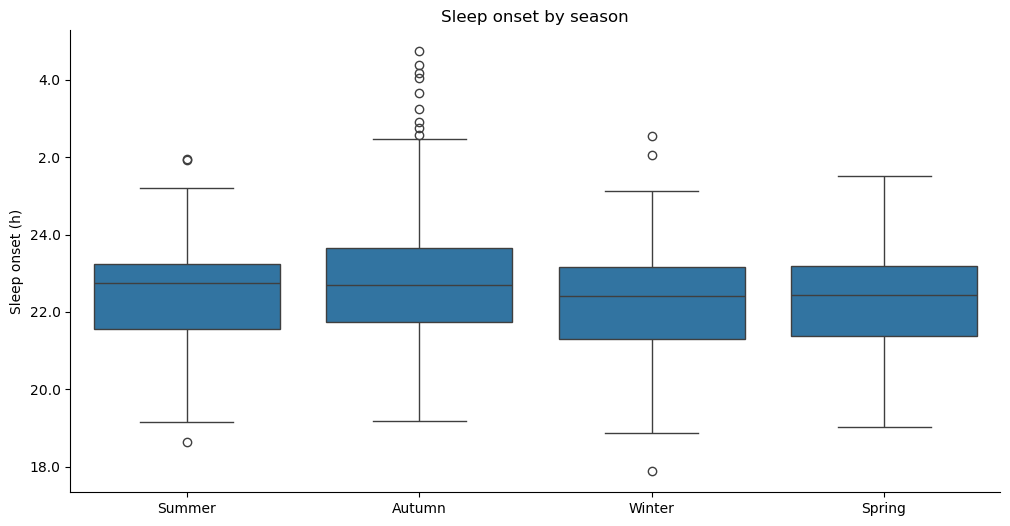

In [66]:
# phase (sleep offset - sunrise) by season
plt.figure(figsize=(12, 6))
sns.boxplot(x='season', y='sleep_start_decimal', data=df2)
plt.title('Sleep onset by season')
plt.suptitle('')  # add space after the title
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
sns.despine()
plt.grid(False)

plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__DST and sleep-wake pattern__

In [67]:
# t-test to compare the midpoint of sleep between DST and non-DST
ttest_midsleep_dst = stats.ttest_ind(df[df['DST_1'] == 0]['midsleep_h'], df[df['DST_1'] == 1]['midsleep_h'])
ttest_sleep_duration_dst = stats.ttest_ind(df1[df1['DST_1'] == 0]['sleep_duration'], df1[df1['DST_1'] == 1]['sleep_duration'])

utest_sleep_start_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_start_decimal'], df[df['DST_1'] == 1]['sleep_start_decimal'])
utest_sleep_end_dst = stats.mannwhitneyu(df[df['DST_1'] == 0]['sleep_end_decimal'], df[df['DST_1'] == 1]['sleep_end_decimal'])
utest_phase_dst = stats.mannwhitneyu(df2[df2['DST_1'] == 0]['phase'], df2[df2['DST_1'] == 1]['phase'])
utest_waso_dst = stats.mannwhitneyu(df3[df3['DST_1'] == 0]['waso'], df3[df3['DST_1'] == 1]['waso'])

In [68]:
print('T test result for the midsleep by DST:')
print(ttest_midsleep_dst)
print('T test result for the sleep duration by DST:')
print(ttest_sleep_duration_dst)
print('U test result for the sleep onset by DST:')
print(utest_sleep_start_dst)
print('U test result for the sleep offset by DST:')
print(utest_sleep_end_dst)
print('U test result for the phase by DST:')
print(utest_phase_dst)
print('U test result for the waso by DST:')
print(utest_waso_dst)

T test result for the midsleep by DST:
TtestResult(statistic=0.3135544024327143, pvalue=0.7539579681491707, df=664.0)
T test result for the sleep duration by DST:
TtestResult(statistic=0.4852074207569695, pvalue=0.6276892607051074, df=664.0)
U test result for the sleep onset by DST:
MannwhitneyuResult(statistic=53242.5, pvalue=0.3756350266641778)
U test result for the sleep offset by DST:
MannwhitneyuResult(statistic=56990.0, pvalue=0.533185574604567)
U test result for the phase by DST:
MannwhitneyuResult(statistic=28929.5, pvalue=1.2724926482140772e-26)
U test result for the waso by DST:
MannwhitneyuResult(statistic=54506.5, pvalue=0.9649050411931701)


In [69]:
# mean and standard deviation of the phase by DST
df_grouped_dst = df.groupby('DST_1').agg({'phase': ['mean', 'std']})
df_grouped_dst = df_grouped_dst.reset_index()
df_grouped_dst.columns = ['DST', 'mean', 'std']

df_grouped_dst

,DST,mean,std
0,0,-0.043328,1.177551
1,1,1.040473,1.348484


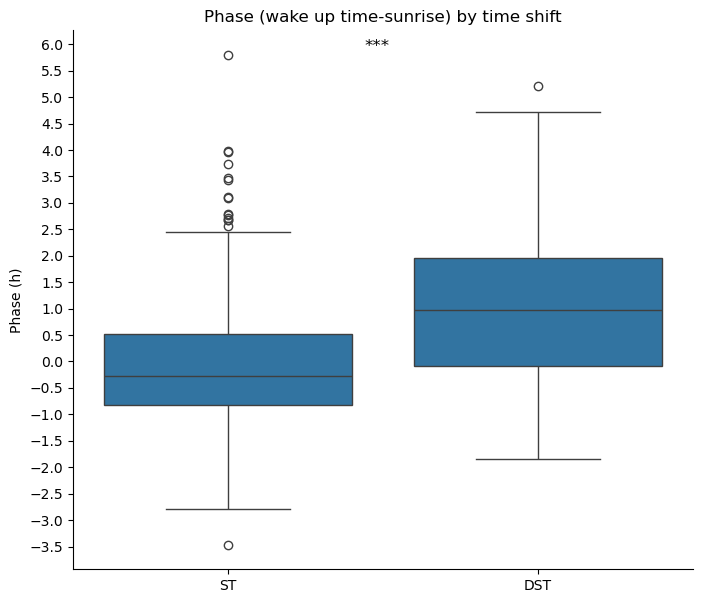

In [70]:
# phase (sleep offset - sunrise) by DST
plt.figure(figsize=(8, 7))
sns.boxplot(x='DST_1', y='phase', data=df2)
plt.title('Phase (wake up time-sunrise) by time shift')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.xticks([0, 1], ['ST', 'DST'])
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('***', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Photoperiod and sleep-wake pattern__

In [71]:
# filter data only for the location
df_uk = df[df['location'] == 'UK']
df_ita = df[df['location'] == 'ITA']

df1_uk = df1[df1['location'] == 'UK'] # sleep duration
df1_ita = df1[df1['location'] == 'ITA']

df2_uk = df2[df2['location'] == 'UK'] # phase
df2_ita = df2[df2['location'] == 'ITA']

df3_uk = df3[df3['location'] == 'UK'] # waso
df3_ita = df3[df3['location'] == 'ITA']

In [72]:
# correlation between sleep-wake variables and photoperiod
correlation1_test1 = stats.pearsonr(df['midsleep_h'], df['photoperiod'])
#correlation1_test2 = stats.pearsonr(df_workdays['midsleep_h'], df_workdays['photoperiod'])
#correlation1_test3 = stats.pearsonr(df_freedays['midsleep_h'], df_freedays['photoperiod'])
correlation1_test4 = stats.pearsonr(df1['sleep_duration'], df1['photoperiod'])
correlation1_test5 = stats.spearmanr(df['sleep_start_decimal'], df['photoperiod'])
correlation1_test6 = stats.spearmanr(df['sleep_end_decimal'], df['photoperiod'])
correlation1_test7 = stats.spearmanr(df3['waso'], df3['photoperiod'])
correlation1_test8 = stats.spearmanr(df2['phase'], df2['photoperiod'])  

In [73]:
# correlation between sleep-wake variables and photoperiod for uk 
correlation2_test1 = stats.pearsonr(df_uk['midsleep_h'], df_uk['photoperiod'])
correlation2_test2 = stats.pearsonr(df1_uk['sleep_duration'], df1_uk['photoperiod'])
correlation2_test3 = stats.spearmanr(df2_uk['phase'], df2_uk['photoperiod'])
correlation2_test4 = stats.spearmanr(df3_uk['waso'], df3_uk['photoperiod'])
correlation2_test5 = stats.spearmanr(df_uk['sleep_start_decimal'], df_uk['photoperiod'])
correlation2_test6 = stats.spearmanr(df_uk['sleep_end_decimal'], df_uk['photoperiod'])

In [74]:
correlation3_test1 = stats.pearsonr(df_ita['midsleep_h'], df_ita['photoperiod'])
correlation3_test2 = stats.pearsonr(df1_ita['sleep_duration'], df1_ita['photoperiod'])
correlation3_test3 = stats.spearmanr(df2_ita['phase'], df2_ita['photoperiod'])
correlation3_test4 = stats.spearmanr(df3_ita['waso'], df3_ita['photoperiod'])
correlation3_test5 = stats.spearmanr(df_ita['sleep_start_decimal'], df_ita['photoperiod'])
correlation3_test6 = stats.spearmanr(df_ita['sleep_end_decimal'], df_ita['photoperiod'])

In [75]:
# extract the coefficients and p-values from the correlation test results
correlation1_coeff = [correlation1_test1.statistic, correlation1_test4.statistic, correlation1_test5.statistic, 
                      correlation1_test6.statistic, correlation1_test7.statistic, correlation1_test8.statistic]

p_values = [correlation1_test1.pvalue, correlation1_test4.pvalue, correlation1_test5.pvalue, 
            correlation1_test6.pvalue, correlation1_test7.pvalue, correlation1_test8.pvalue]

In [76]:
# extract the coefficients and p-values from the correlation test results for UK
correlation2_coeff = [correlation2_test1.statistic, correlation2_test2.statistic, correlation2_test3.statistic,
                      correlation2_test4.statistic, correlation2_test5.statistic, correlation2_test6.statistic]

p_values_uk = [correlation2_test1.pvalue, correlation2_test2.pvalue, correlation2_test3.pvalue,
                correlation2_test4.pvalue, correlation2_test5.pvalue, correlation2_test6.pvalue]

In [77]:
# extract the coefficients and p-values from the correlation test results for ITA
correlation3_coeff = [correlation3_test1.statistic, correlation3_test2.statistic, correlation3_test3.statistic,
                      correlation3_test4.statistic, correlation3_test5.statistic, correlation3_test6.statistic]

p_values_ita = [correlation3_test1.pvalue, correlation3_test2.pvalue, correlation3_test3.pvalue,
                correlation3_test4.pvalue, correlation3_test5.pvalue, correlation3_test6.pvalue]

In [78]:
# create a DataFrame with the results
correlation1_results = pd.DataFrame({
    'Variables': ['midsleep vs photoperiod', 'sleep duration vs photoperiod', 'sleep onset vs photoperiod', 
                  'sleep offset vs photoperiod', 'WASO(min) vs photoperiod', 'phase vs photoperiod'],
    'Coefficient': correlation1_coeff,
    'P-value': p_values
})

correlation1_results

,Variables,Coefficient,P-value
0,midsleep vs photoperiod,-0.051302,1.860612e-01
1,sleep duration vs photoperiod,0.054189,1.624592e-01
2,sleep onset vs photoperiod,-0.022664,5.593165e-01
3,sleep offset vs photoperiod,-0.018105,6.409399e-01
4,WASO(min) vs photoperiod,0.035022,3.686640e-01
5,phase vs photoperiod,0.638865,1.145164e-77


In [79]:
# create a DataFrame with the results for UK
correlation2_results = pd.DataFrame({
    'Variables_UK': ['midsleep vs photoperiod', 'sleep duration vs photoperiod', 'phase vs photoperiod', 
                  'WASO(min) vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod'],
    'Coefficient': correlation2_coeff,
    'P-value': p_values_uk
})

correlation2_results

,Variables_UK,Coefficient,P-value
0,midsleep vs photoperiod,-0.056266,3.499683e-01
1,sleep duration vs photoperiod,0.134678,2.472568e-02
2,phase vs photoperiod,0.724013,2.019406e-46
3,WASO(min) vs photoperiod,0.108673,7.145835e-02
4,sleep onset vs photoperiod,-0.074106,2.180511e-01
5,sleep offset vs photoperiod,0.022208,7.123816e-01


In [80]:
# create a DataFrame with the results for ITA
correlation3_results = pd.DataFrame({
    'Variables_ITA': ['midsleep vs photoperiod', 'sleep duration vs photoperiod', 'phase vs photoperiod', 
                  'WASO(min) vs photoperiod', 'sleep onset vs photoperiod', 'sleep offset vs photoperiod'],
    'Coefficient': correlation3_coeff,
    'P-value': p_values_ita
})

correlation3_results

,Variables_ITA,Coefficient,P-value
0,midsleep vs photoperiod,-0.051349,3.130393e-01
1,sleep duration vs photoperiod,-0.017258,7.347087e-01
2,phase vs photoperiod,0.552623,2.085210e-32
3,WASO(min) vs photoperiod,-0.025556,6.171524e-01
4,sleep onset vs photoperiod,0.020492,6.873999e-01
5,sleep offset vs photoperiod,-0.065033,2.011716e-01


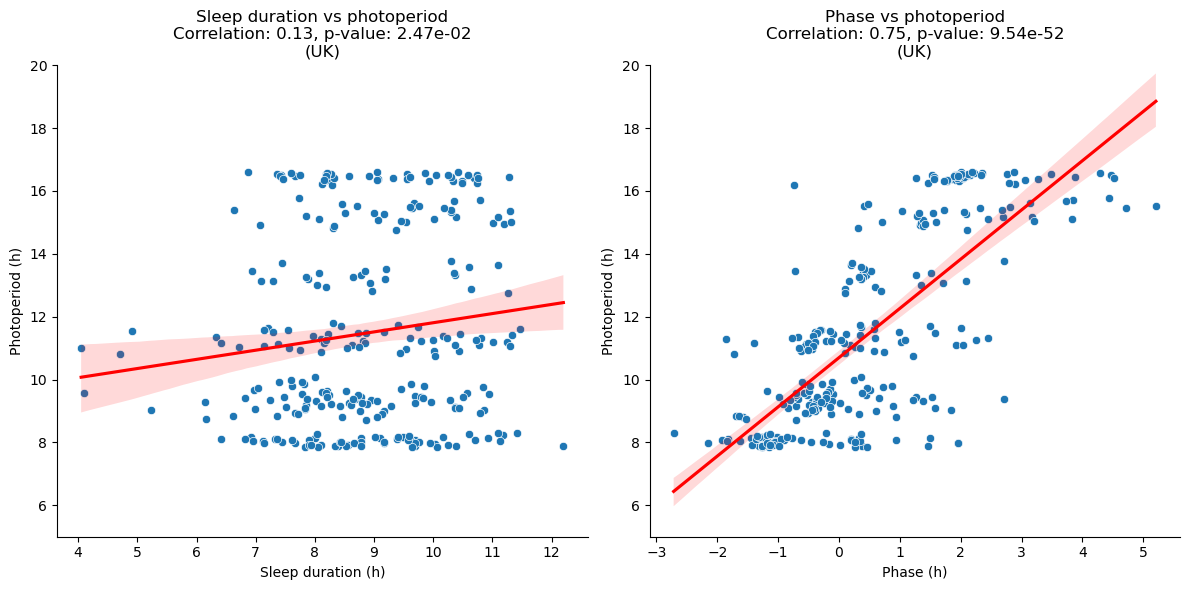

In [81]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(x='sleep_duration', y='photoperiod', data=df1_uk)
sns.regplot(x='sleep_duration', y='photoperiod', data=df1_uk, scatter=False, color='red')
corr_x, p_x = stats.pearsonr(df1_uk['sleep_duration'], df1_uk['photoperiod'])
plt.title(f'Sleep duration vs photoperiod\nCorrelation: {corr_x:.2f}, p-value: {p_x:.2e}\n(UK)')
plt.xlabel('Sleep duration (h)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.subplot(1, 2, 2)
sns.scatterplot(x='phase', y='photoperiod', data=df2_uk)
sns.regplot(x='phase', y='photoperiod', data=df2_uk, scatter=False, color='red')
corr_y, p_y = stats.pearsonr(df2_uk['phase'], df2_uk['photoperiod'])
plt.title(f'Phase vs photoperiod\nCorrelation: {corr_y:.2f}, p-value: {p_y:.2e}\n(UK)')
plt.xlabel('Phase (h)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(5, 20)

plt.tight_layout()
plt.show()

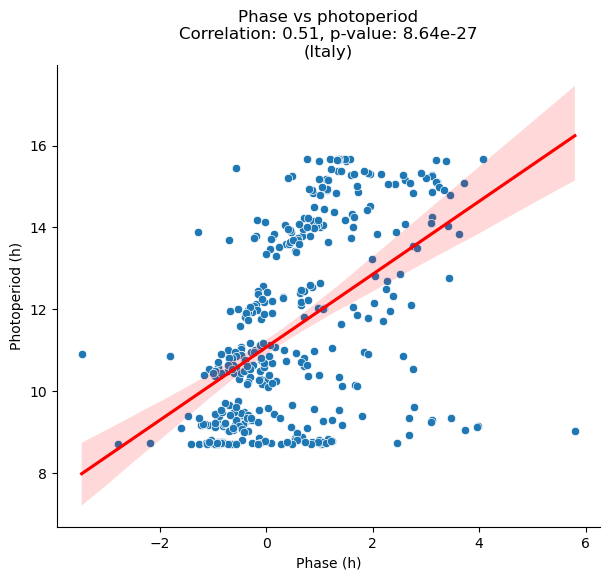

In [82]:
# plot the correlation between the midpoint of sleep and photoperiod, for all the data, work days and free days
plt.figure(figsize=(7, 6))
sns.scatterplot(x='phase', y='photoperiod', data=df2_ita)
sns.regplot(x='phase', y='photoperiod', data=df2_ita, scatter=False, color='red')
corr_x, p_x = stats.pearsonr(df2_ita['phase'], df2_ita['photoperiod'])
plt.title(f'Phase vs photoperiod\nCorrelation: {corr_x:.2f}, p-value: {p_x:.2e}\n(Italy)') 
plt.xlabel('Phase (h)')
plt.ylabel('Photoperiod (h)')
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)

plt.show()

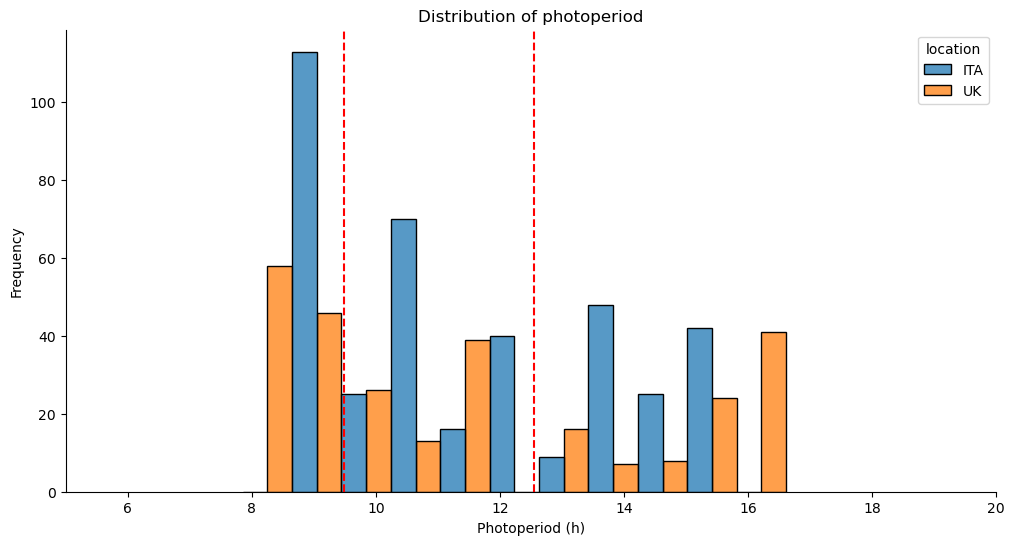

In [83]:
# distribution of the photoperiod
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='photoperiod', kde=False, hue='location', multiple='dodge')
plt.title('Distribution of photoperiod')
plt.xlabel('Photoperiod (h)')
plt.ylabel('Frequency')

# Add vertical lines for the tertiles
tertiles = df['photoperiod'].quantile([1/3, 2/3])
for tertile in tertiles:
    plt.axvline(tertile, color='r', linestyle='--')

plt.xlim(5, 20)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.show()

In [84]:
# define the tertile of the photoperiod
df['photoperiod_tertile'] = pd.qcut(df['photoperiod'], 3, labels=['short', 'medium', 'long'])
df2['photoperiod_tertile'] = pd.qcut(df2['photoperiod'], 3, labels=['short', 'medium', 'long'])
df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2368887206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])


In [85]:
# print the threshold for the tertiles
print('Tertiles for the photoperiod:')
print(tertiles)

Tertiles for the photoperiod:
0.333333     9.477778
0.666667    12.555556
Name: photoperiod, dtype: float64


In [86]:
# what is photoperiod terile
df_grouped_tertile = df.groupby('photoperiod_tertile').describe()

df_grouped_tertile = df_grouped_tertile.transpose()
df_grouped_tertile = df_grouped_tertile.reset_index()

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\1811407222.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_grouped_tertile = df.groupby('photoperiod_tertile').describe()


In [87]:
#add a column in df, df1, df2, df3 with the photoperiod tertile
df['photoperiod_tertile'] = pd.qcut(df['photoperiod'], 3, labels=['short', 'medium', 'long'])
df1['photoperiod_tertile'] = pd.qcut(df1['photoperiod'], 3, labels=['short', 'medium', 'long'])
df2['photoperiod_tertile'] = pd.qcut(df2['photoperiod'], 3, labels=['short', 'medium', 'long'])
df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\886733539.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['photoperiod_tertile'] = pd.qcut(df3['photoperiod'], 3, labels=['short', 'medium', 'long'])


In [88]:
#compare the variables between the photoperiod tertiles
ttest_midsleep_tertile = stats.f_oneway(df[df['photoperiod_tertile'] == 'short']['midsleep_h'], 
                                        df[df['photoperiod_tertile'] == 'medium']['midsleep_h'], 
                                        df[df['photoperiod_tertile'] == 'long']['midsleep_h'])

ttest_duration_tertile = stats.f_oneway(df1[df1['photoperiod_tertile'] == 'short']['sleep_duration'],
                                        df1[df1['photoperiod_tertile'] == 'medium']['sleep_duration'],
                                        df1[df1['photoperiod_tertile'] == 'long']['sleep_duration'])

utest_phase_tertile = stats.kruskal(df2[df2['photoperiod_tertile'] == 'short']['phase'],
                                    df2[df2['photoperiod_tertile'] == 'medium']['phase'],
                                    df2[df2['photoperiod_tertile'] == 'long']['phase'])

utest_start_tertile = stats.kruskal(df[df['photoperiod_tertile'] == 'short']['sleep_start_decimal'],
                                    df[df['photoperiod_tertile'] == 'medium']['sleep_start_decimal'],
                                    df[df['photoperiod_tertile'] == 'long']['sleep_start_decimal'])

utest_end_tertile = stats.kruskal(df[df['photoperiod_tertile'] == 'short']['sleep_end_decimal'],
                                    df[df['photoperiod_tertile'] == 'medium']['sleep_end_decimal'],
                                    df[df['photoperiod_tertile'] == 'long']['sleep_end_decimal'])

utest_waso_tertile = stats.kruskal(df3[df3['photoperiod_tertile'] == 'short']['waso'],
                                    df3[df3['photoperiod_tertile'] == 'medium']['waso'],
                                    df3[df3['photoperiod_tertile'] == 'long']['waso'])

In [89]:
print('ANOVA results for midsleep by photoperiod tertile:')
print(ttest_midsleep_tertile)
print('ANOVA results for sleep duration by photoperiod tertile:')
print(ttest_duration_tertile)
print('Kruskal-Wallis results for phase by photoperiod tertile:')
print(utest_phase_tertile)
print('Kruskal-Wallis results for sleep start by photoperiod tertile:')
print(utest_start_tertile)
print('Kruskal-Wallis results for sleep end by photoperiod tertile:')
print(utest_end_tertile)
print('Kruskal-Wallis results for waso by photoperiod tertile:')
print(utest_waso_tertile)

ANOVA results for midsleep by photoperiod tertile:
F_onewayResult(statistic=1.5391288318857812, pvalue=0.21533360009239336)
ANOVA results for sleep duration by photoperiod tertile:
F_onewayResult(statistic=2.4803005824403788, pvalue=0.08449459278790962)
Kruskal-Wallis results for phase by photoperiod tertile:
KruskalResult(statistic=251.65644687975458, pvalue=2.2568198465885974e-55)
Kruskal-Wallis results for sleep start by photoperiod tertile:
KruskalResult(statistic=0.8187182208532348, pvalue=0.6640757129847934)
Kruskal-Wallis results for sleep end by photoperiod tertile:
KruskalResult(statistic=1.1434208755357114, pvalue=0.5645589694089153)
Kruskal-Wallis results for waso by photoperiod tertile:
KruskalResult(statistic=7.888072318528169, pvalue=0.019369876851725965)


In [90]:
# define different df for the 3 photoperiod tertiles
df_short = df[df['photoperiod_tertile'] == 'short']
df_medium = df[df['photoperiod_tertile'] == 'medium']
df_long = df[df['photoperiod_tertile'] == 'long']

In [91]:
# ttest between Ita and UK photoperiod in shorter photoperiod
ttest_midsleep_short = stats.ttest_ind(df_short[df_short['location'] == 'ITA']['midsleep_h'], df_short[df_short['location'] == 'UK']['midsleep_h'])
ttest_duration_short = stats.ttest_ind(df_short[df_short['location'] == 'ITA']['sleep_duration'], df_short[df_short['location'] == 'UK']['sleep_duration'])

utest_phase_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['phase'], df_short[df_short['location'] == 'UK']['phase'])
utest_start_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['sleep_start_decimal'], df_short[df_short['location'] == 'UK']['sleep_start_decimal'])
utest_end_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['sleep_end_decimal'], df_short[df_short['location'] == 'UK']['sleep_end_decimal'])
utest_waso_short = stats.mannwhitneyu(df_short[df_short['location'] == 'ITA']['waso'].dropna(), df_short[df_short['location'] == 'UK']['waso'].dropna())

In [92]:
# print the results
print('T test results by location for shorter photoperiod')
print('Midsleep:', ttest_midsleep_short)
print('Sleep duration:', ttest_duration_short)
print('U test results by location for shorter photoperiod')
print('Phase:', utest_phase_short)
print('Sleep onset:', utest_start_short)
print('Sleep offset:', utest_end_short)
print('WASO:', utest_waso_short)

T test results by location for shorter photoperiod
Midsleep: TtestResult(statistic=2.421471016267581, pvalue=0.01626833364067653, df=220.0)
Sleep duration: TtestResult(statistic=0.4705265730502681, pvalue=0.638445001481827, df=220.0)
U test results by location for shorter photoperiod
Phase: MannwhitneyuResult(statistic=7203.0, pvalue=0.02738486097189133)
Sleep onset: MannwhitneyuResult(statistic=6486.0, pvalue=0.480155777386273)
Sleep offset: MannwhitneyuResult(statistic=7691.5, pvalue=0.0012463011826794425)
WASO: MannwhitneyuResult(statistic=5027.0, pvalue=0.024567213842032254)


In [93]:
# test between Ita and UK photoperiod in longer photoperiod
ttest_long_midsleep = stats.ttest_ind(df_long[df_long['location'] == 'ITA']['midsleep_h'], df_long[df_long['location'] == 'UK']['midsleep_h'])
ttest_long_sleep_duration = stats.ttest_ind(df_long[df_long['location'] == 'ITA']['sleep_duration'], df_long[df_long['location'] == 'UK']['sleep_duration'])

utest_long_phase = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['phase'], df_long[df_long['location'] == 'UK']['phase'])
utest_long_start = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['sleep_start_decimal'], df_long[df_long['location'] == 'UK']['sleep_start_decimal'])
utest_long_end = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['sleep_end_decimal'], df_long[df_long['location'] == 'UK']['sleep_end_decimal'])
utest_long_waso = stats.mannwhitneyu(df_long[df_long['location'] == 'ITA']['waso'].dropna(), df_long[df_long['location'] == 'UK']['waso'].dropna())

In [94]:
#print the results
print('T test results for longer photoperiod:')
print('T test midsleep:', ttest_long_midsleep)
print('T test sleep duration:', ttest_long_sleep_duration)
print('U test results for longer photoperiod:')
print('U test phase:', utest_long_phase)
print('U test sleep onset:', utest_long_start)
print('U test sleep offset:', utest_long_end)
print('U test waso:', utest_long_waso)

T test results for longer photoperiod:
T test midsleep: TtestResult(statistic=2.2887399527014174, pvalue=0.023043671625895632, df=220.0)
T test sleep duration: TtestResult(statistic=-1.8545574432126575, pvalue=0.06499762035540738, df=220.0)
U test results for longer photoperiod:
U test phase: MannwhitneyuResult(statistic=4729.0, pvalue=0.005419489793550682)
U test sleep onset: MannwhitneyuResult(statistic=7418.0, pvalue=0.0038697534083831455)
U test sleep offset: MannwhitneyuResult(statistic=6790.5, pvalue=0.11756292094274318)
U test waso: MannwhitneyuResult(statistic=4282.5, pvalue=0.0005436209171242682)


In [95]:
# bonferroni correction
alpha = 0.001
n_tests = 12
alpha_corrected = alpha / n_tests

alpha_corrected

8.333333333333333e-05

In [96]:
# mean and standard deviation of the sleep var by photoperiod tertile and location
midsleep_phot_loc = df.groupby(['photoperiod_tertile', 'location']).agg({'sleep_end_decimal': ['mean', 'std'], 'sleep_start_decimal': ['mean', 'std'], 
                                                                             'phase': ['mean', 'std'], 'waso': ['mean', 'std']})
midsleep_phot_loc = midsleep_phot_loc.reset_index()
midsleep_phot_loc.columns = ['Photoperiod', 'Location', 'Mean wake up time', 'Std wake up time', 'Mean sleep onset', 'Std sleep onset', 
                                  'Mean phase', 'Std phase', 'Mean WASO', 'Std WASO']

midsleep_phot_loc

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\136410357.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  midsleep_phot_loc = df.groupby(['photoperiod_tertile', 'location']).agg({'sleep_end_decimal': ['mean', 'std'], 'sleep_start_decimal': ['mean', 'std'],


,Photoperiod,Location,Mean wake up time,Std wake up time,Mean sleep onset,Std sleep onset,Mean phase,Std phase,Mean WASO,Std WASO
0,short,ITA,31.648132,1.320171,22.780532,1.875084,-0.019397,1.375445,48.269565,30.143319
1,short,UK,31.211164,0.960797,22.434355,1.247134,-0.432704,1.003138,55.849057,27.743997
2,medium,ITA,31.296689,0.905347,22.586073,1.408552,0.113128,0.970374,43.205479,28.183614
3,medium,UK,31.145943,0.795333,22.499013,1.694002,0.063487,0.856067,53.200000,33.532961
4,long,ITA,31.416997,1.029727,22.566601,1.340493,1.432870,1.096485,48.580645,32.767497
5,long,UK,31.258507,1.031932,22.078819,1.417564,1.879687,1.228039,62.494737,28.168518


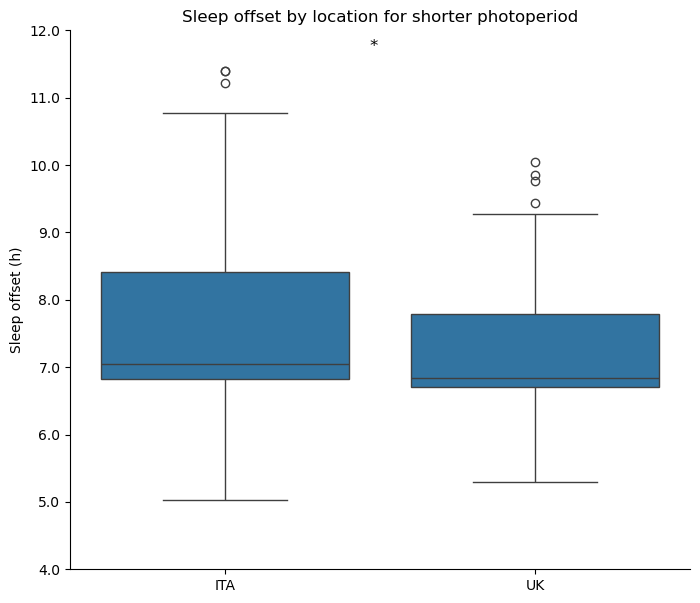

In [97]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='sleep_end_decimal', data=df_short)
plt.title('Sleep offset by location for shorter photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep offset (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.ylim(28, 36)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.gca().invert_xaxis()
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

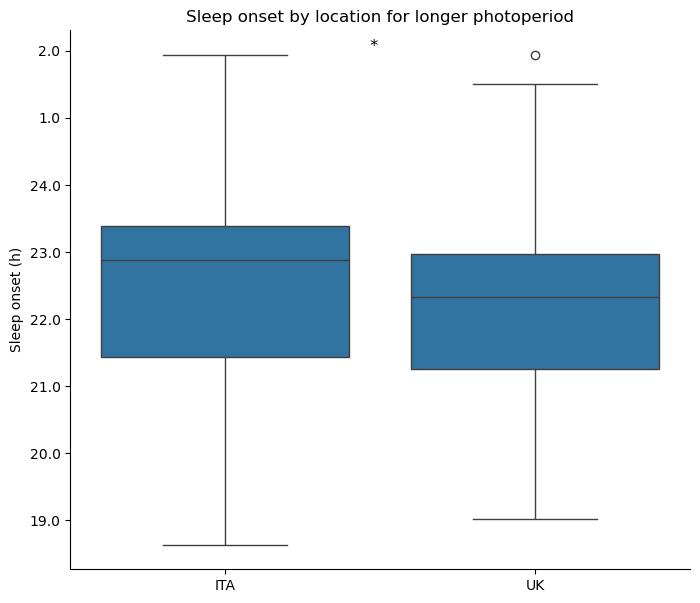

In [98]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='sleep_start_decimal', data=df_long)
plt.title('Sleep onset by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(1))
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

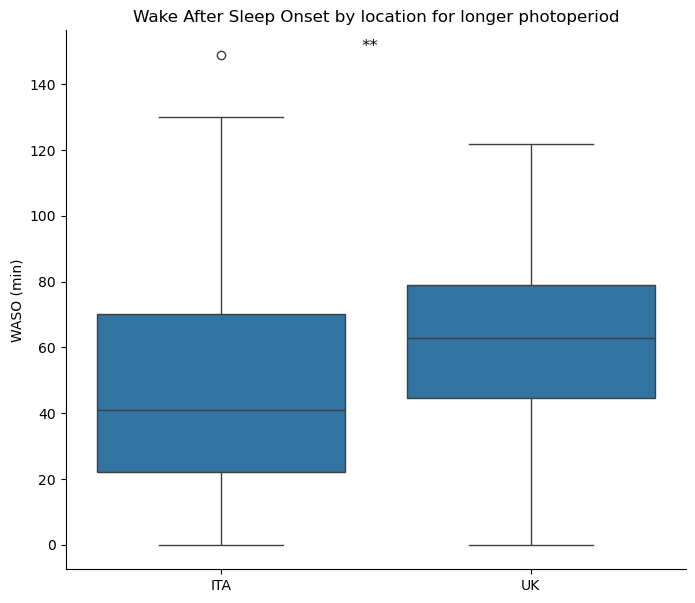

In [99]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='waso', data=df_long)
plt.title('Wake After Sleep Onset by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('WASO (min)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.annotate('**', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

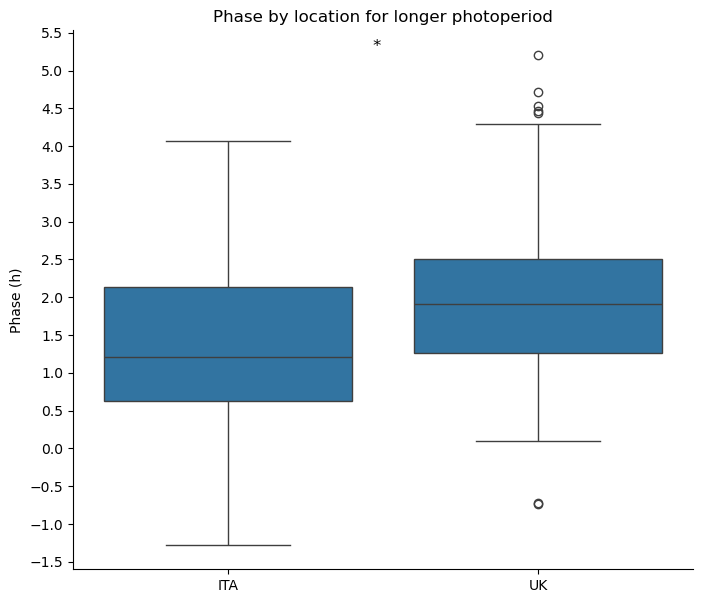

In [100]:
plt.figure(figsize=(8, 7))
sns.boxplot(x='location', y='phase', data=df_long)
plt.title('Phase by location for longer photoperiod')
plt.suptitle('')  # Removing default subtitle
plt.ylabel('Phase (h)')
plt.xlabel('')
sns.despine()
plt.grid(False)
plt.gca().yaxis.set_major_locator(MultipleLocator(0.5))
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
plt.show()

__Weekly IV, IS and RA__

In [101]:
# load the datasets required for the analysis
weekly_values = pd.read_csv(fpath + '\\2.0_weekly_IV_IS_RA_values_with_dates.csv')
weekly_jetlag = weekly_means_jetlag

In [102]:
# split Date_Range into Start_Date and End_Date in weekly_values
weekly_values[['Start_Date', 'End_Date']] = weekly_values['Date_Range'].str.split(' to ', expand=True)

In [103]:
# convert Start_Date and End_Date to datetime format
weekly_values['Start_Date'] = pd.to_datetime(weekly_values['Start_Date'])
weekly_values['End_Date'] = pd.to_datetime(weekly_values['End_Date'])

In [104]:
# merge by matching the week number extracted from Start_Date with week_of_year in weekly_jetlag
merged_data = pd.merge(
    weekly_values,
    weekly_jetlag,
    left_on=weekly_values['Start_Date'].dt.isocalendar().week,
    right_on='week_of_year',
    how='inner'
)

In [105]:
merged_data.head()

,week_of_year,Date_Range,IS,IV,RA,Start_Date,End_Date,free days,work days,jet lag,location
0,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,26.491667,27.608333,-1.116667,ITA
1,41,2022-10-12 to 2022-10-18,0.593843,0.089441,0.945319,2022-10-12,2022-10-18,27.766670,26.637500,1.129170,UK
2,42,2022-10-19 to 2022-10-25,0.592888,0.086393,0.934961,2022-10-19,2022-10-25,25.385417,26.045000,-0.659583,UK
3,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,26.570833,28.237500,-1.666667,ITA
4,43,2022-10-26 to 2022-11-01,0.615197,0.086685,0.958284,2022-10-26,2022-11-01,24.129167,26.030208,-1.901042,UK


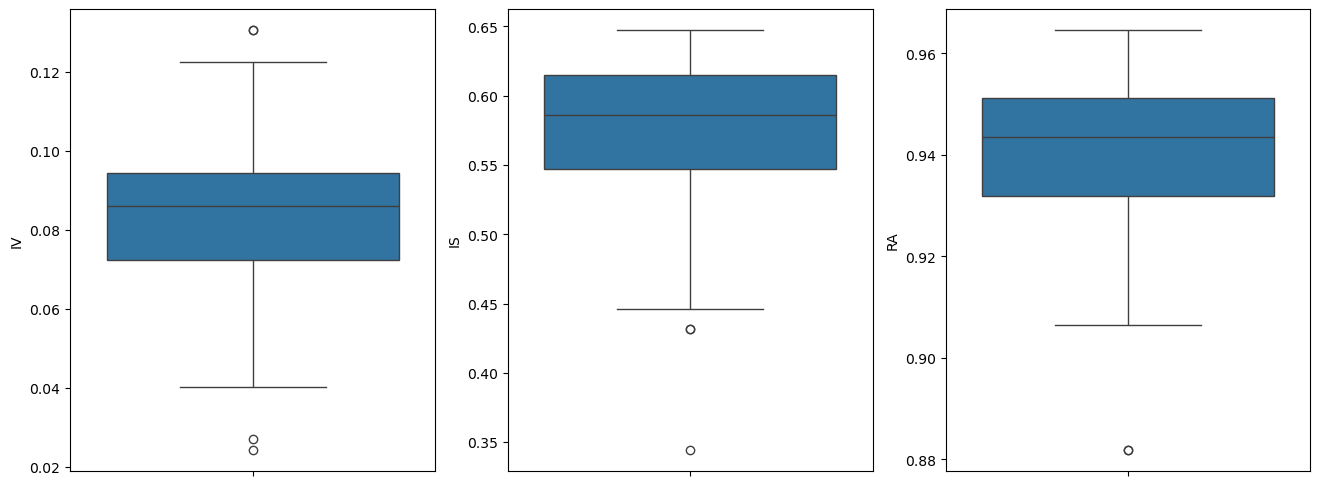

In [106]:
# box plot to verify the outliers in IV, IS, and RA
fig, ax = plt.subplots(1, 3, figsize=(16, 6))
sns.boxplot(data=merged_data['IV'], ax=ax[0])
sns.boxplot(data=merged_data['IS'], ax=ax[1])
sns.boxplot(data=merged_data['RA'], ax=ax[2])
plt.show()

In [107]:
# summary statistics
summary_stats = merged_data.groupby("location")[['IV', 'IS', 'RA']].describe()

summary_stats

IV                                                              \
         count      mean       std       min       25%       50%       75%   
location                                                                     
ITA       63.0  0.081875  0.021206  0.024172  0.068838  0.084375  0.093261   
UK        45.0  0.087831  0.016381  0.053677  0.075640  0.086685  0.097674   

                      IS            ...                        RA            \
               max count      mean  ...       75%       max count      mean   
location                            ...                                       
ITA       0.130562  58.0  0.576607  ...  0.615054  0.647358  60.0  0.942044   
UK        0.130562  43.0  0.572043  ...  0.612777  0.645810  43.0  0.938983   

                                                                      
               std       min       25%       50%       75%       max  
location                                                              
ITA       0.015210  0.881815  0.932905  0.943610  0.951849  0.964584  
UK        0.016212  0.881815  0.931148  0.942958  0.948727  0.962952  

[2 rows x 24 columns]

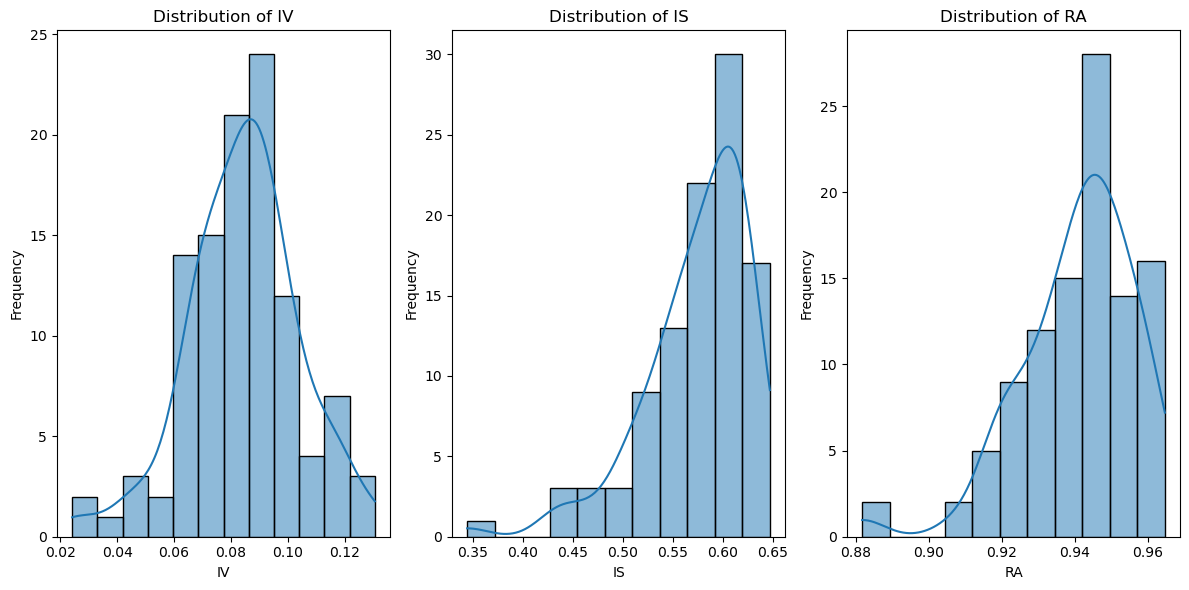

In [108]:
# distribution of IV, IS, and RA
plt.figure(figsize=(12, 6))

plt.subplot(1, 3, 1)
sns.histplot(merged_data['IV'].dropna(), kde=True)
plt.title('Distribution of IV')
plt.xlabel('IV')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
sns.histplot(merged_data['IS'].dropna(), kde=True)
plt.title('Distribution of IS')
plt.xlabel('IS')
plt.ylabel('Frequency')
 
plt.subplot(1, 3, 3)
sns.histplot(merged_data['RA'].dropna(), kde=True)
plt.title('Distribution of RA')
plt.xlabel('RA')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [109]:
# compare the variables between ITA and UK
iv_ttest = stats.ttest_ind(merged_data[merged_data['location'] == 'ITA']['IV'], merged_data[merged_data['location'] == 'UK']['IV'], nan_policy='omit')
is_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['IS'], merged_data[merged_data['location'] == 'UK']['IS'], nan_policy='omit')
ra_utest = stats.mannwhitneyu(merged_data[merged_data['location'] == 'ITA']['RA'], merged_data[merged_data['location'] == 'UK']['RA'], nan_policy='omit')

In [110]:
print('Test results for IV by location:', iv_ttest)
print('Test results for IS by location:', is_utest)
print('Test results for RA by location:', ra_utest)

Test results for IV by location: TtestResult(statistic=-1.5767935413484517, pvalue=0.11782288955003352, df=106.0)
Test results for IS by location: MannwhitneyuResult(statistic=1317.0, pvalue=0.6330928748997473)
Test results for RA by location: MannwhitneyuResult(statistic=1434.0, pvalue=0.33719076262194314)


------------------------

__Sleep-wake patterns over time__

In [111]:
# remove outliers
# criteria: zscore of 3 means that the data point is 3 standard deviations away from the mean
df = df[(np.abs(stats.zscore(df['midsleep_h'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_start_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_end_decimal'])) < 3)]
df = df[(np.abs(stats.zscore(df['phase'])) < 3)]
df = df[(np.abs(stats.zscore(df['sleep_duration'])) < 3)]

In [112]:
# filter data only for the location
df_uk = df[df['location'] == 'UK']
df_ita = df[df['location'] == 'ITA']

df1_uk = df1[df1['location'] == 'UK'] # sleep duration
df1_ita = df1[df1['location'] == 'ITA']

df2_uk = df2[df2['location'] == 'UK'] # phase
df2_ita = df2[df2['location'] == 'ITA']

df3_uk = df3[df3['location'] == 'UK'] # waso
df3_ita = df3[df3['location'] == 'ITA']

In [113]:
# filter df to have only day_after_flight 1,2,8,9
df_flight_uk = df_uk[df_uk['day_after_flight'].isin([1, 2, 8, 9])]
df_flight_ita = df_ita[df_ita['day_after_flight'].isin([1, 2, 8, 9])]
df1_flight_uk = df1_uk[df1_uk['day_after_flight'].isin([1, 2, 8, 9])]
df1_flight_ita = df1_ita[df1_ita['day_after_flight'].isin([1, 2, 8, 9])]
df2_flight_uk = df2_uk[df2_uk['day_after_flight'].isin([1, 2, 8, 9])]
df2_flight_ita = df2_ita[df2_ita['day_after_flight'].isin([1, 2, 8, 9])]
df3_flight_uk = df3_uk[df3_uk['day_after_flight'].isin([1, 2, 8, 9])]
df3_flight_ita = df3_ita[df3_ita['day_after_flight'].isin([1, 2, 8, 9])]

In [114]:
df_flight = df[df['day_after_flight'].isin([1, 2, 8, 9])]
df1_flight = df1[df1['day_after_flight'].isin([1, 2, 8, 9])] # sleep duration
df2_flight = df2[df2['day_after_flight'].isin([1, 2, 8, 9])] # phase
df3_flight = df3[df3['day_after_flight'].isin([1, 2, 8, 9])] # waso

In [115]:
# new column with the day after flight day 1 and 2 as '0' and day 8 and 9 as '1'
df_flight_uk['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight_uk['day_after_flight'].isin([1, 2]), '0', '1')
df_flight_ita['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight_ita['day_after_flight'].isin([1, 2]), '0', '1')

df1_flight_uk['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df1_flight_uk['day_after_flight'].isin([1, 2]), '0', '1')
df1_flight_ita['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df1_flight_ita['day_after_flight'].isin([1, 2]), '0', '1')

df2_flight_uk['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df2_flight_uk['day_after_flight'].isin([1, 2]), '0', '1')
df2_flight_ita['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df2_flight_ita['day_after_flight'].isin([1, 2]), '0', '1')

df3_flight_uk['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df3_flight_uk['day_after_flight'].isin([1, 2]), '0', '1')
df3_flight_ita['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df3_flight_ita['day_after_flight'].isin([1, 2]), '0', '1')

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\4140043693.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_flight_uk['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight_uk['day_after_flight'].isin([1, 2]), '0', '1')
C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\4140043693.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_flight_ita['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight_ita['day_after_flight'].isin([1, 2]), '0', '1')
C:\Users\gg00642\AppData\Loc

In [116]:
df_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight['day_after_flight'].isin([1, 2]), '0', '1')
df1_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df1_flight['day_after_flight'].isin([1, 2]), '0', '1')
df2_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df2_flight['day_after_flight'].isin([1, 2]), '0', '1')
df3_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df3_flight['day_after_flight'].isin([1, 2]), '0', '1')   

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\986408874.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df_flight['day_after_flight'].isin([1, 2]), '0', '1')
C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\986408874.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1_flight['day_after_flight_group(0=day1&2;1=day8&9)'] = np.where(df1_flight['day_after_flight'].isin([1, 2]), '0', '1')
C:\Users\gg00642\AppData\Local\Temp\ipyker

In [117]:
df_flight_uk = df_flight_uk.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df_flight_ita = df_flight_ita.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

df1_flight_uk = df1_flight_uk.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df1_flight_ita = df1_flight_ita.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

df2_flight_uk = df2_flight_uk.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df2_flight_ita = df2_flight_ita.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

df3_flight_uk = df3_flight_uk.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df3_flight_ita = df3_flight_ita.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

In [118]:
df_flight = df_flight.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df1_flight = df1_flight.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df2_flight = df2_flight.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})
df3_flight = df3_flight.rename(columns={'day_after_flight_group(0=day1&2;1=day8&9)': 'day_after_flight_group'})

_Sleep onset_

In [119]:
model1 = smf.mixedlm('sleep_start_decimal ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model1.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_start_decimal
No. Observations: 644     Method:             REML               
No. Groups:       47      Scale:              1.7176             
Min. group size:  1       Log-Likelihood:     -1105.9219         
Max. group size:  46      Converged:          Yes                
Mean group size:  13.7                                           
------------------------------------------------------------------
                  Coef.   Std.Err.     z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept         22.331     0.101  221.347  0.000  22.133  22.529
day_after_flight   0.007     0.009    0.758  0.448  -0.011   0.024
Group Var          0.100     0.038                                



In [245]:
model2 = smf.mixedlm('sleep_start_decimal ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                MixedLM    Dependent Variable:    sleep_start_decimal
No. Observations:     644        Method:                REML               
No. Groups:           47         Scale:                 1.7058             
Min. group size:      1          Log-Likelihood:        -1107.1196         
Max. group size:      46         Converged:             Yes                
Mean group size:      13.7                                                 
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       22.352    0.132 168.921 0.000 22.092 22.611
location[T.UK]                   0.146    0.219   0.665 0.506 -0.284  0.576
day_after_flight                 0.013    0.010   1.344 0.179 -0.006  0.032
location[T.UK]:day_after_flight

In [121]:
# shapiro-wilk test for sleep_start_decimal
shapiro_test_sleep_start = stats.shapiro(df_flight_uk['sleep_start_decimal'])

shapiro_test_sleep_start

ShapiroResult(statistic=0.9727645719514576, pvalue=0.07820723497244873)

In [246]:
ttest_start_days_uk = stats.ttest_ind(df_flight_uk[df_flight_uk['day_after_flight_group'] == '0']['sleep_start_decimal'],
                                        df_flight_uk[df_flight_uk['day_after_flight_group'] == '1']['sleep_start_decimal'])

ttest_start_days_uk

TtestResult(statistic=2.3734823902288693, pvalue=0.02001949582884101, df=80.0)

In [123]:
# mean and std of sleep_start_decimal by day_after_flight_group 
df_grouped_flight_uk = df_flight_uk.groupby(['day_after_flight_group']).agg({'sleep_start_decimal': ['mean', 'std']})
df_grouped_flight_uk


sleep_start_decimal          
                                      mean       std
day_after_flight_group                              
0                                22.822287  1.415886
1                                22.104915  1.310500

In [250]:
# shapiro-wilk test for sleep_start_decimal
shapiro_test_sleep_start = stats.shapiro(df_flight_ita['sleep_start_decimal'])

shapiro_test_sleep_start

ShapiroResult(statistic=0.9946365306389271, pvalue=0.9787322761727537)

In [251]:
ttest_start_days_ita = stats.ttest_ind(df_flight_ita[df_flight_ita['day_after_flight_group'] == '0']['sleep_start_decimal'],
                                       df_flight_ita[df_flight_ita['day_after_flight_group'] == '1']['sleep_start_decimal'])    

ttest_start_days_ita

TtestResult(statistic=1.0341649793137544, pvalue=0.30395841680459273, df=86.0)

In [252]:
# mean and std of sleep_start_decimal by day_after_flight_group 
df_grouped_flight_ita = df_flight_ita.groupby(['day_after_flight_group']).agg({'sleep_start_decimal': ['mean', 'std']})
df_grouped_flight_ita

sleep_start_decimal          
                                      mean       std
day_after_flight_group                              
0                                22.571809  1.314914
1                                22.272358  1.399653

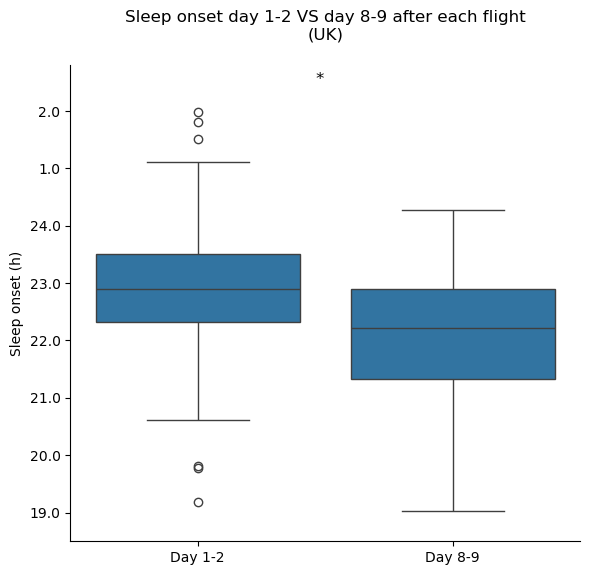

In [253]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='sleep_start_decimal', data=df_flight_uk)
plt.title('Sleep onset day 1-2 VS day 8-9 after each flight\n(UK)\n')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep onset (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
plt.ylim(18.5, 26.8)
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [267]:
# Fit a mixed-effects model with random intercepts and slopes for location and flight_id
model5 = smf.mixedlm('sleep_start_decimal ~ C(location) + photoperiod + day_after_flight',
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

              Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_start_decimal
No. Observations: 644     Method:             REML               
No. Groups:       47      Scale:              1.7153             
Min. group size:  1       Log-Likelihood:     -1108.4393         
Max. group size:  46      Converged:          Yes                
Mean group size:  13.7                                           
------------------------------------------------------------------
                   Coef.   Std.Err.    z     P>|z|  [0.025  0.975]
------------------------------------------------------------------
Intercept          22.723     0.341  66.585  0.000  22.054  23.392
C(location)[T.UK]  -0.183     0.145  -1.266  0.205  -0.467   0.100
photoperiod        -0.025     0.027  -0.940  0.347  -0.077   0.027
day_after_flight    0.004     0.009   0.477  0.633  -0.013   0.022
Group Var           0.102     0.039                               



In [268]:
coef_onset = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_onset

,coef,p-value,0.025,0.975
Intercept,22.722952,0.000000,22.054092,23.391812
C(location)[T.UK],-0.183189,0.205403,-0.466726,0.100347
photoperiod,-0.025067,0.347244,-0.077336,0.027202
day_after_flight,0.004232,0.633352,-0.013157,0.021621
Group Var,0.059675,0.042932,0.001899,0.117451


In [269]:
#drop non significant variables
coef_onset = coef_onset.drop('Intercept')
coef_onset = coef_onset.drop('Group Var', axis=0)

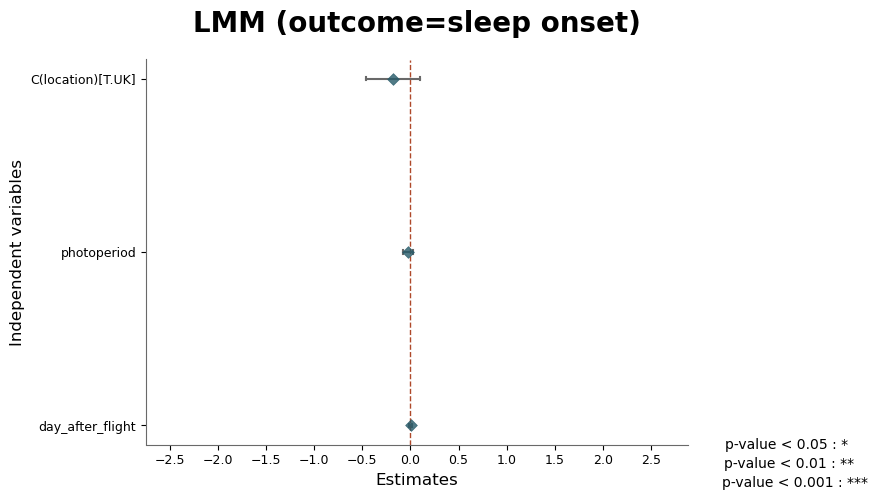

In [271]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_onset.index, data=coef_onset, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_onset.shape[0]):
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.025'].iloc[i], coef_onset['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_onset['0.975'].iloc[i], coef_onset['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_onset.shape[0]):
    if coef_onset['p-value'].iloc[i] < 0.001:
        plt.text(coef_onset['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.01:
        plt.text(coef_onset['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_onset['p-value'].iloc[i] < 0.06:
        plt.text(coef_onset['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=sleep onset)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.89)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


#ax.set_yticklabels(['Location [T.UK]', 'Photoperiod', 'Location [T.UK]*Photoperiod','Days after flight', 'Location [T.UK]*Days after flight'], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

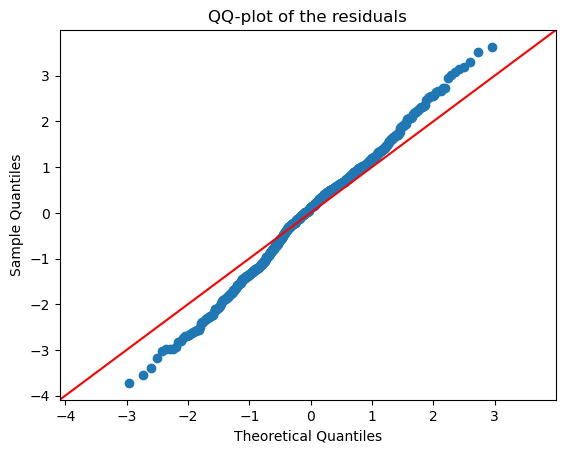

In [132]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [133]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [134]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 3.4896338426842513, p-value: 0.6249567369541909
The residuals are homoscedastic (fail to reject H0).


In [135]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.9224674019416803


In [136]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

In [137]:
#extract from df sunrise and sunset times for both the UK and Italy and create a new dataframe df_daylight
df_daylight1 = pd.read_excel(fpath + '\\1.0_sunset_sunrise_UTC.xlsx', sheet_name='Sheet1')

In [138]:
def adjust_value(row):
    timeshift = row['DST(0=ST)']
    
    if timeshift == 1:
                return row['sunrise (uk), hours'] + 1, row['sunset (uk), hours'] + 1, row['sunrise (ita), hours'] + 2, row['sunset (ita), hours'] + 2
    elif timeshift == 0:
                return row['sunrise (uk), hours'] - 0, row['sunset (uk), hours'] - 0, row['sunrise (ita), hours'] + 1, row['sunset (ita), hours'] + 1
    
    return row['sunrise (uk), hours'], row['sunset (uk), hours'], row['sunrise (ita), hours'], row['sunset (ita), hours']

df_daylight1[['sunrise (uk), hours_adjust', 'sunset (uk), hours_adjust', 'sunrise (ita), hours_adjust', 'sunset (ita), hours_adjust']] = df_daylight1.apply(adjust_value, axis=1, result_type='expand')

In [139]:
#add 24 hours to the sleep_start_decimal and sleep_end_decimal
df['sleep_end_decimal_plot'] = df['sleep_end_decimal'] - 24
df['sleep_end_decimal_UTC_plot'] = df['sleep_end_decimal_UTC'] - 24

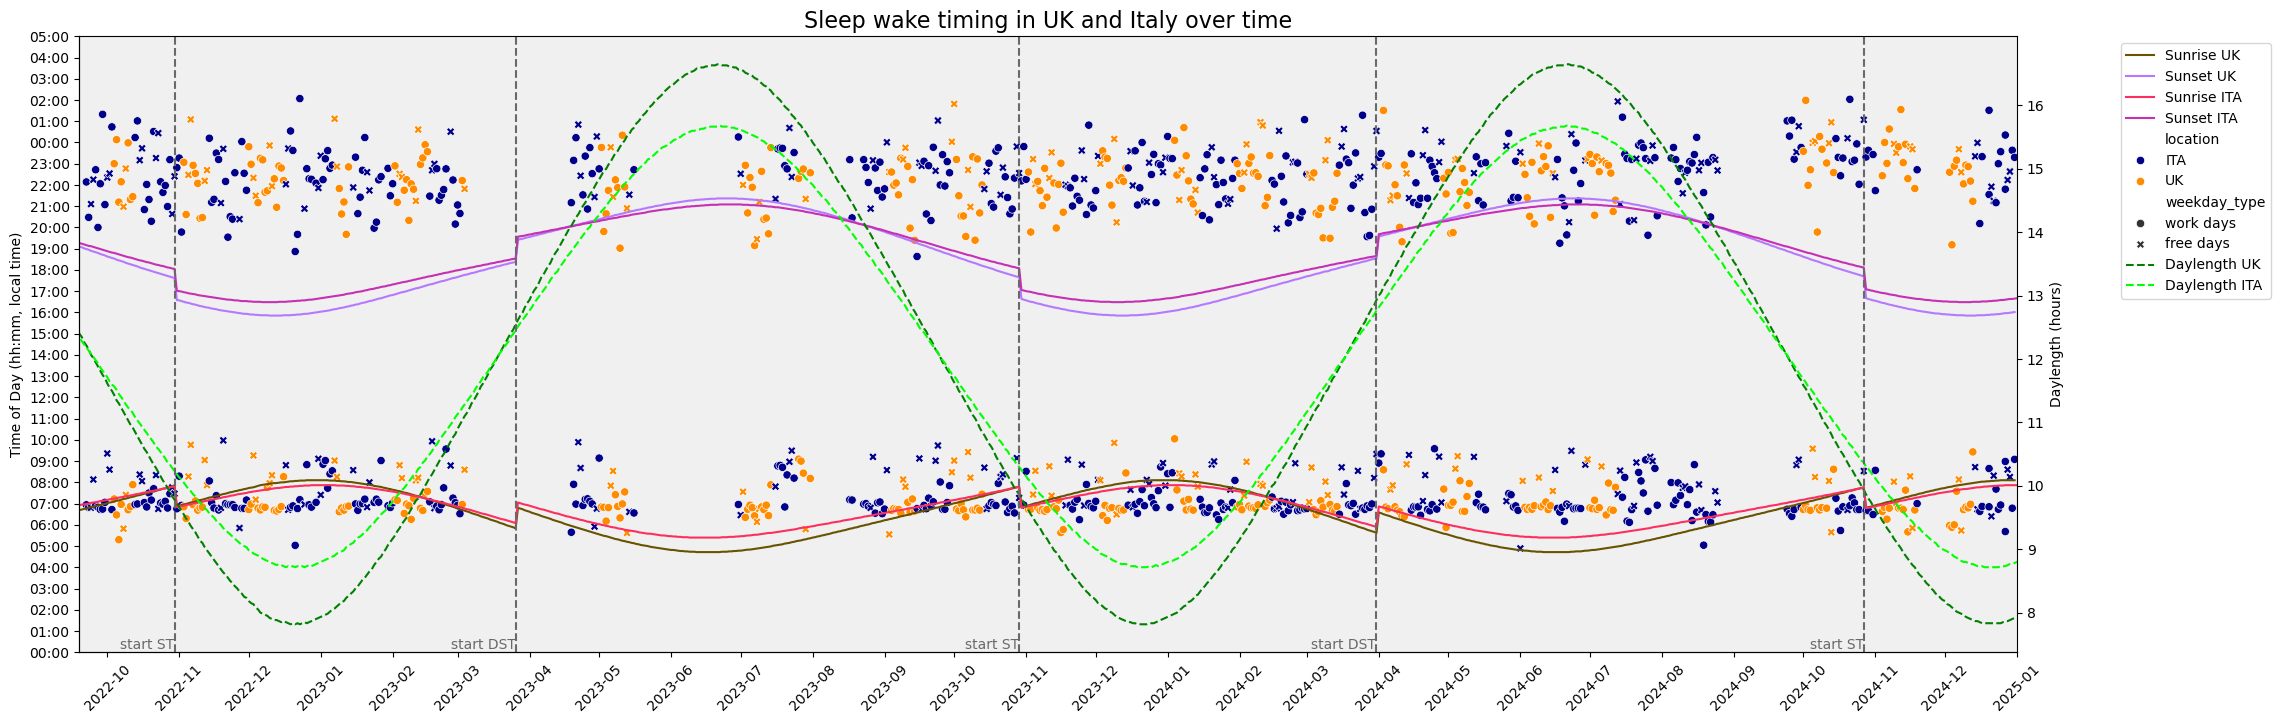

In [140]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_plot', hue='location', data=df, style='weekday_type', palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours_adjust'] - df_daylight1['sunrise (uk), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours_adjust'] - df_daylight1['sunrise (ita), hours_adjust'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, local time)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start ST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

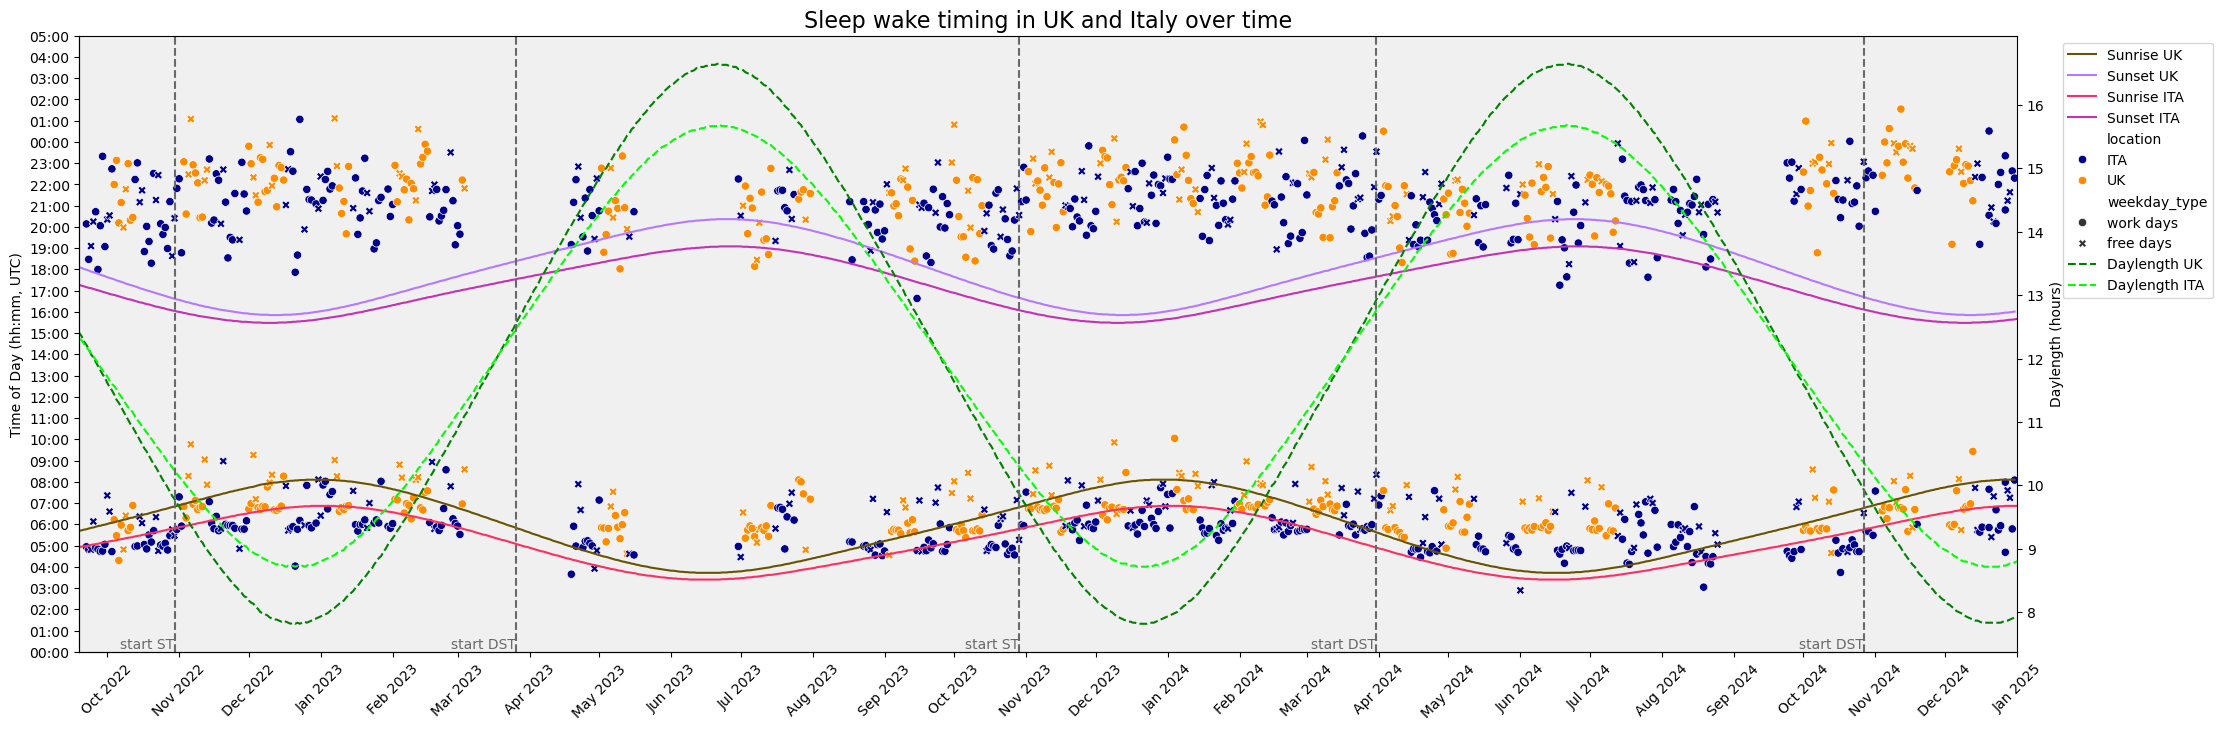

In [141]:
# Add a third y-axis for daylight length
fig, ax1 = plt.subplots(figsize=(25, 8))

# Remove spines
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Add gray background
ax1.set_facecolor('#f0f0f0')

# UK sunrise and sunset
sns.lineplot(x='date', y='sunrise (uk), hours', data=df_daylight1, label='Sunrise UK', color='#675300', ax=ax1)
sns.lineplot(x='date', y='sunset (uk), hours', data=df_daylight1, label='Sunset UK', color='#b578ff', ax=ax1)

# ITA sunrise and sunset
sns.lineplot(x='date', y='sunrise (ita), hours', data=df_daylight1, label='Sunrise ITA', color='#fd2f60', ax=ax1)
sns.lineplot(x='date', y='sunset (ita), hours', data=df_daylight1, label='Sunset ITA', color='#c530b4', ax=ax1)

# sleep onset and offset
sns.scatterplot(x='date', y='sleep_start_decimal_UTC', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)
sns.scatterplot(x='date', y='sleep_end_decimal_UTC_plot', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'], legend='full', ax=ax1)

# Add a third y-axis for daylight length
ax2 = ax1.twinx()
sns.lineplot(x='date', y=df_daylight1['sunset (uk), hours'] - df_daylight1['sunrise (uk), hours'], data=df_daylight1, ax=ax2, label='Daylength UK', color='green', linestyle='--')
sns.lineplot(x='date', y=df_daylight1['sunset (ita), hours'] - df_daylight1['sunrise (ita), hours'], data=df_daylight1, ax=ax2, label='Daylength ITA', color='lime', linestyle='--')

# Adding labels and title
ax1.set_xlabel('')
ax1.set_ylabel('Time of Day (hh:mm, UTC)')
ax1.set_title('Sleep wake timing in UK and Italy over time', fontsize=16)
ax2.set_ylabel('Daylength (hours)')

# Remove space y axis and plot
plt.gca().margins(x=0)

# Format y-axis to hh:mm
ax1.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))

# 3 hours interval on y-axis
ax1.set_yticks(range(0, 30, 1))
ax1.set_yticklabels([hours_to_hhmm(i % 24, None) for i in range(0, 30, 1)])

#set ax2 y interval
ax2.set_yticks(range(8, 17, 1))

# Remove space y axis and plot
ax1.margins(x=0)

# Adding legend to the right of the plot
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
by_label = dict(zip(labels1 + labels2, handles1 + handles2))
ax1.legend(by_label.values(), by_label.keys(), bbox_to_anchor=(1.02, 1), loc='upper left')
ax2.get_legend().remove()

# Set x-axis major locator of ax1
ax1.xaxis.set_major_locator(mdates.MonthLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

# Add vertical lines and text for DST and ST
for date, label in [('2022-10-30', 'start ST'), ('2023-10-29', 'start ST'), ('2023-03-26', 'start DST'), ('2024-03-31', 'start DST'), ('2024-10-27', 'start DST')]:
    plt.axvline(x=pd.to_datetime(date), color='dimgrey', linestyle='--')
    plt.text(pd.to_datetime(date), plt.ylim()[0], label, ha='right', va='bottom', color='dimgray')

plt.xlim(pd.to_datetime('2022-09-19'), pd.to_datetime('2025-01-01'))

plt.show()

_Midsleep_

In [142]:
# Order the data by date
df = df.sort_values(by='date')
df_flight_sorted = df.sort_values(by='date')

In [143]:
model1 = smf.mixedlm('midsleep_h ~ day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  midsleep_h
No. Observations:   644      Method:              REML      
No. Groups:         47       Scale:               0.8062    
Min. group size:    1        Log-Likelihood:      -858.4794 
Max. group size:    46       Converged:           Yes       
Mean group size:    13.7                                    
------------------------------------------------------------
                 Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept        26.796    0.066 408.646 0.000 26.667 26.924
day_after_flight  0.005    0.006   0.804 0.421 -0.007  0.016
Group Var         0.027    0.021                            



In [144]:
model2 = smf.mixedlm('midsleep_h ~ day_after_flight + location + location*day_after_flight', df, groups=df['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                   Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       midsleep_h
No. Observations:        644           Method:                   REML      
No. Groups:              47            Scale:                    0.8028    
Min. group size:         1             Log-Likelihood:           -859.5289 
Max. group size:         46            Converged:                Yes       
Mean group size:         13.7                                              
---------------------------------------------------------------------------
                                Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------
Intercept                       26.837    0.083 323.620 0.000 26.675 27.000
location[T.UK]                   0.045    0.141   0.315 0.753 -0.232  0.321
day_after_flight                 0.008    0.006   1.297 0.195 -0.004  0.021
location[T.UK]:day_after_flight

In [145]:
shapiro_test_midsleep = stats.shapiro(df_flight_uk['midsleep_h'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9788581161039187, pvalue=0.19446950320837314)

In [146]:
ttest_midsleep_days_uk = stats.ttest_ind(df_flight_uk[df_flight_uk['day_after_flight_group'] == '0']['midsleep_h'],
                                        df_flight_uk[df_flight_uk['day_after_flight_group'] == '1']['midsleep_h'])

ttest_midsleep_days_uk

TtestResult(statistic=2.392457908957092, pvalue=0.01908057477433197, df=80.0)

In [147]:
# mean and std by day_after_flight_group 
df_grouped_flight_uk = df_flight_uk.groupby(['day_after_flight_group']).agg({'midsleep_h': ['mean', 'std']})
df_grouped_flight_uk


midsleep_h          
                             mean       std
day_after_flight_group                     
0                       27.091473  1.030899
1                       26.594444  0.826807

In [148]:
shapiro_test_midsleep = stats.shapiro(df_flight_ita['midsleep_h'])

shapiro_test_midsleep

ShapiroResult(statistic=0.9892075355070158, pvalue=0.6872154432888357)

In [256]:
ttest_midsleep_days_ita = stats.ttest_ind(df_flight_ita[df_flight_ita['day_after_flight_group'] == '0']['midsleep_h'],
                                        df_flight_ita[df_flight_ita['day_after_flight_group'] == '1']['midsleep_h'])

ttest_midsleep_days_ita

TtestResult(statistic=0.6971167636078306, pvalue=0.48760994659737944, df=86.0)

In [150]:
df_grouped_flight_ita = df_flight_ita.groupby(['day_after_flight_group']).agg({'midsleep_h': ['mean', 'std']})
df_grouped_flight_ita

midsleep_h          
                             mean       std
day_after_flight_group                     
0                       27.048050  0.835002
1                       26.915854  0.944040

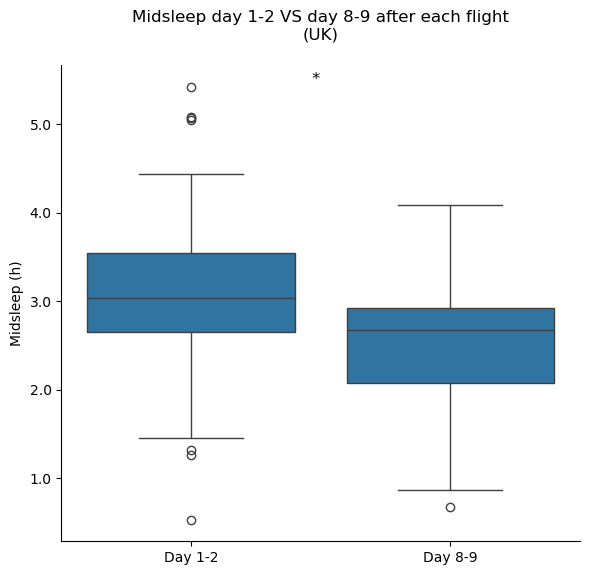

In [257]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='midsleep_h', data=df_flight_uk)
plt.title('Midsleep day 1-2 VS day 8-9 after each flight\n(UK)\n')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Midsleep (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 26.8)
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

In [281]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5 = smf.mixedlm('midsleep_h ~ C(location) + day_after_flight + photoperiod + DST_1', 
                      data=df, groups=df['flight_id']).fit(method='powell', maxiter=1000)

print(model5.summary())

            Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  midsleep_h
No. Observations:    644      Method:              REML      
No. Groups:          47       Scale:               0.8051    
Min. group size:     1        Log-Likelihood:      -860.8888 
Max. group size:     46       Converged:           Yes       
Mean group size:     13.7                                    
-------------------------------------------------------------
                  Coef.  Std.Err.    z    P>|z| [0.025 0.975]
-------------------------------------------------------------
Intercept         27.266    0.259 105.161 0.000 26.758 27.774
C(location)[T.UK] -0.167    0.086  -1.942 0.052 -0.335  0.002
day_after_flight   0.003    0.006   0.428 0.669 -0.009  0.014
photoperiod       -0.042    0.025  -1.668 0.095 -0.092  0.007
DST_1              0.216    0.132   1.634 0.102 -0.043  0.476
Group Var          0.021    0.020                            



In [153]:
# calculate log-likelihood of model2a
#ll_model5 = model5.llf
#ll_model5 = model5.llf

# calculate likelihood ratio Chi-Squared test statistic
#lr_test1 = 2 * (ll_model5 - model5.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
#p_value = stats.chi2.sf(lr_test1, 2)

#print('Likelihood ratio test results:')
#print('Chi-Squared test statistic:', lr_test1)
#print('P-value:', p_value)

In [282]:
coef_midsleep = pd.DataFrame({'coef': model5.params.values, 'p-value': model5.pvalues.values, '0.025': model5.conf_int()[0], '0.975': model5.conf_int()[1]})
coef_midsleep

,coef,p-value,0.025,0.975
Intercept,27.265989,0.000000,26.757814,27.774164
C(location)[T.UK],-0.166865,0.052107,-0.335252,0.001522
day_after_flight,0.002529,0.668908,-0.009063,0.014122
photoperiod,-0.042178,0.095222,-0.091726,0.007369
DST_1,0.216430,0.102362,-0.043253,0.476113
Group Var,0.026044,0.246924,-0.018042,0.070129


In [283]:
#drop non significant variables
coef_midsleep = coef_midsleep.drop('Intercept')
coef_midsleep = coef_midsleep.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2801289528.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Photoperiod', 'Time shift[T.DST]'], fontsize=9)


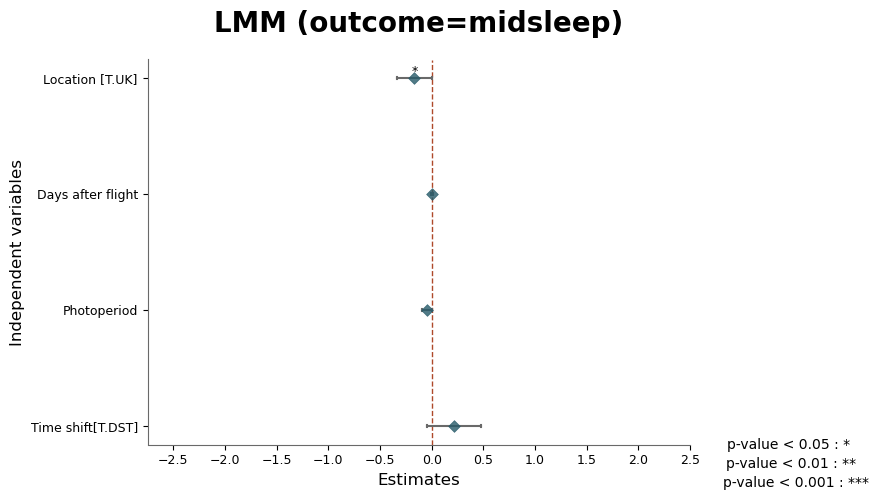

In [284]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_midsleep.index, data=coef_midsleep, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_midsleep.shape[0]):
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.025'].iloc[i], coef_midsleep['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_midsleep['0.975'].iloc[i], coef_midsleep['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_midsleep.shape[0]):
    if coef_midsleep['p-value'].iloc[i] < 0.001:
        plt.text(coef_midsleep['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.01:
        plt.text(coef_midsleep['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_midsleep['p-value'].iloc[i] < 0.06:
        plt.text(coef_midsleep['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=midsleep)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location [T.UK]', 'Days after flight', 'Photoperiod', 'Time shift[T.DST]'], fontsize=9)

plt.show()

<Figure size 800x600 with 0 Axes>

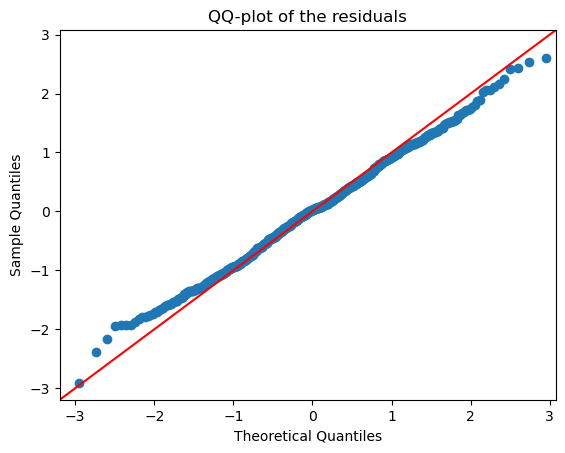

In [157]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [158]:
residualsY = model5.resid 
predictedY = model5.fittedvalues

In [159]:
# Breusch-Pagan test for homoscedasticity
bp_testY = het_breuschpagan(residualsY, model5.model.exog)

# results of the Breusch-Pagan test
bp_statY, bp_pvalY, _, _ = bp_testY
print(f'Breusch-Pagan statistic: {bp_statY}, p-value: {bp_pvalY}')
if bp_pvalY > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 6.202968433594645, p-value: 0.28696725794708294
The residuals are homoscedastic (fail to reject H0).


In [160]:
# Durbin-Watson test for autocorrelation
durbin_watson_testY = durbin_watson(residualsY)

print('Durbin-Watson test:', durbin_watson_testY)

Durbin-Watson test: 1.6901394678030954


In [161]:
# The Durbin-Watson test statistic is close to 2, which indicates that there is no significant autocorrelation in the residuals

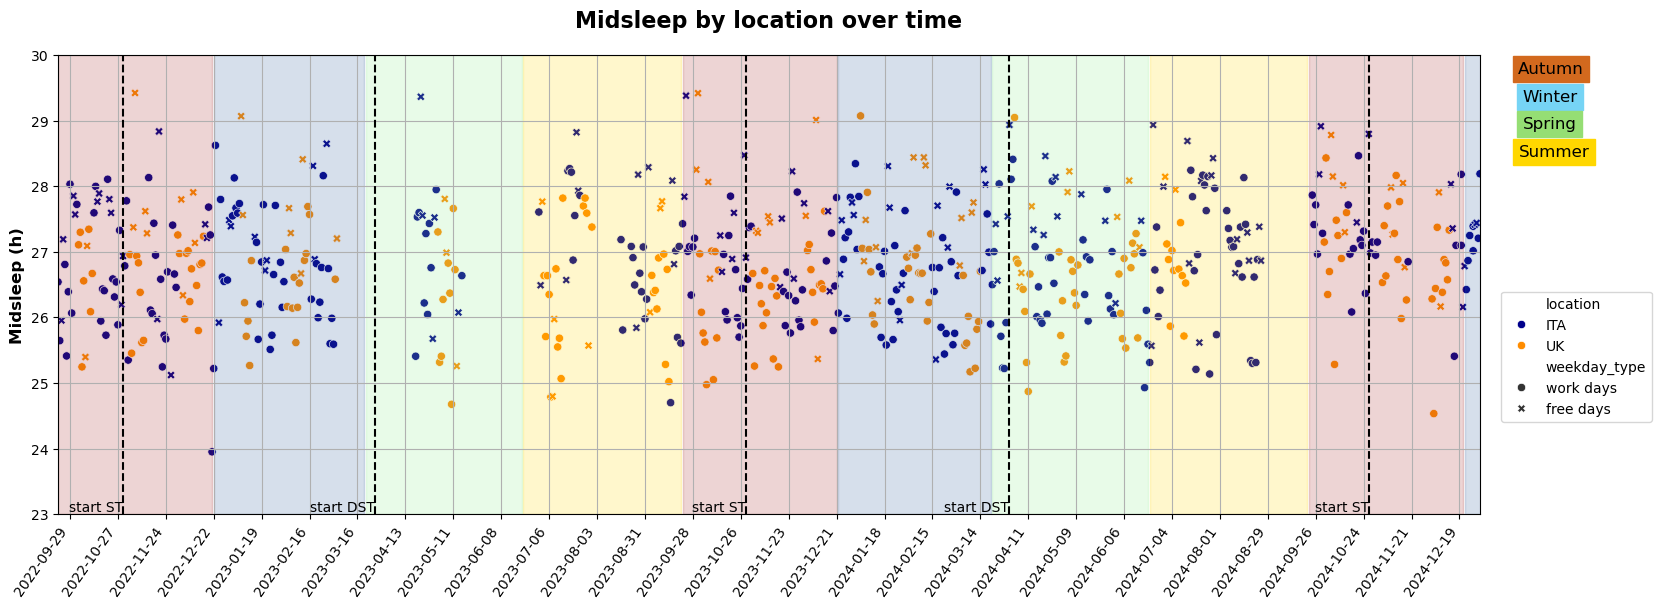

In [162]:
plt.figure(figsize=(15, 6))
sns.scatterplot(x='date', y='midsleep_h', hue='location', style='weekday_type', data=df, palette=['darkblue', 'darkorange'])
plt.title('Midsleep by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h)', fontsize=12, fontweight='bold')
plt.xlabel('')
plt.legend()
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 0.5)) 
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca
plt.ylim(23,30)

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start ST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.052, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.05, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.049, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.049, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

# mean of the phase for the two locations
#plt.axhline(y=df[df['location'] == 'ITA']['phase'].mean(), color='darkblue', linestyle='--', label='Mean ITA')
#plt.text(plt.xlim()[1], df[df['location'] == 'ITA']['phase'].mean(), 'Mean ITA', ha='right', va='bottom')
#plt.axhline(y=df[df['location'] == 'UK']['phase'].mean(), color='darkorange', linestyle='--', label='Mean UK')
#plt.text(plt.xlim()[1], df[df['location'] == 'UK']['phase'].mean(), 'Mean UK', ha='right', va='bottom')

#plt.xlim(pd.to_datetime('2024-03-28'), pd.to_datetime('2024-04-27'))

plt.show()

_Phase (wake up time - sunrise)_

In [163]:
# test the skewness of the phase data
skewness = skew(df2['phase'])

print(f"Index of skewness: {skewness}")

Index of skewness: 0.6891833435185114


In [164]:
# test the kurtosis of the phase data
kurtosis_value = kurtosis(df2['phase'])

print(f"Index of kurtosis: {kurtosis_value}")

Index of kurtosis: 0.27283960285683184


In [165]:
#phase_data = df2['phase'].values.reshape(-1, 1)

# apply the Yeo-Johnson transformation
#pt = PowerTransformer(method='yeo-johnson')
#phase_transformed = pt.fit_transform(phase_data)

In [166]:
# add the transformed phase to the dataframe 
#df2['phase_transformed'] = phase_transformed

In [167]:
# test the best distribution for the phase data
distributions = ['norm', 'gamma', 'lognorm', 'expon']
best_fit_results = {}

In [168]:
# Filter out invalid values (e.g., negative values or zeros) for distributions that require positive values
valid_phase = df2["phase"][df2["phase"] > 0]

for dist_name in distributions:
    dist = getattr(stats, dist_name)
    if dist_name in ['gamma', 'lognorm', 'expon']:
        params = dist.fit(valid_phase)
        ks_stat, ks_pval = stats.kstest(valid_phase, dist_name, args=params)
    else:
        params = dist.fit(df2["phase"])
        ks_stat, ks_pval = stats.kstest(df2["phase"], dist_name, args=params)
    best_fit_results[dist_name] = ks_stat  # save the KS statistic

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\scipy\stats\_continuous_distns.py:6545: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


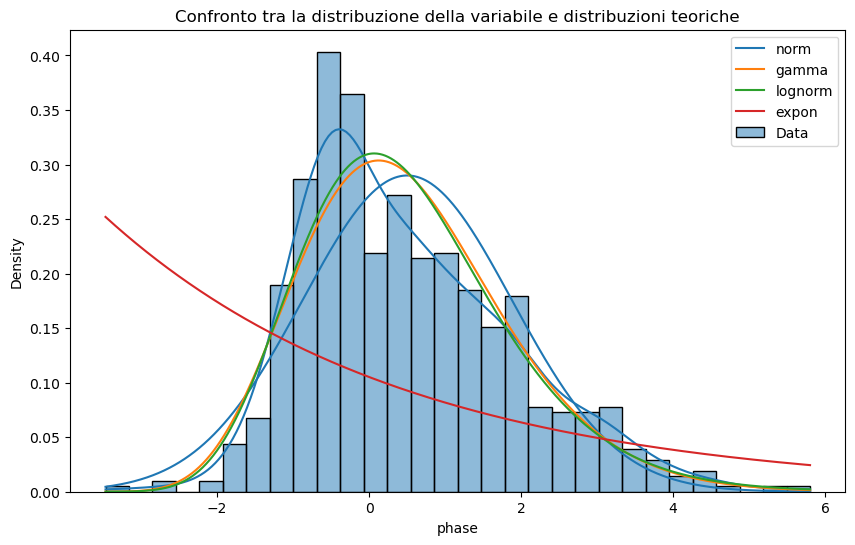

In [169]:
# plot of the best fit results
fig, ax = plt.subplots(figsize=(10, 6))

sns.histplot(df2["phase"], bins=30, kde=True, stat="density", label="Data", ax=ax)

x = np.linspace(df2["phase"].min(), df2["phase"].max(), 1000)

# Disegniamo le distribuzioni teoriche
for dist_name in best_fit_results.keys():
    dist = getattr(stats, dist_name)
    params = dist.fit(df2["phase"])
    pdf = dist.pdf(x, *params)
    ax.plot(x, pdf, label=f"{dist_name}")

ax.legend()
ax.set_title("Confronto tra la distribuzione della variabile e distribuzioni teoriche")
plt.show()

In [170]:
# Shapiro-Wilk test for the transformed phase
shapiro_test_phase = stats.shapiro(df2['phase'])
shapiro_test_phase

ShapiroResult(statistic=0.9626282705791135, pvalue=5.474629945466521e-12)

In [171]:
model1 = smf.mixedlm('phase ~ day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model1.summary())

           Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  phase    
No. Observations:   666      Method:              REML     
No. Groups:         47       Scale:               0.9255   
Min. group size:    2        Log-Likelihood:      -990.2559
Max. group size:    46       Converged:           Yes      
Mean group size:    14.2                                   
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept         0.662    0.170  3.895 0.000  0.329  0.996
day_after_flight -0.012    0.007 -1.773 0.076 -0.025  0.001
Group Var         1.152    0.278                           



In [172]:
model2 = smf.mixedlm('phase ~ day_after_flight + C(location) + C(location)*day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        phase    
No. Observations:         666            Method:                    REML     
No. Groups:               47             Scale:                     0.9269   
Min. group size:          2              Log-Likelihood:            -993.5658
Max. group size:          46             Converged:                 Yes      
Mean group size:          14.2                                               
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.690    0.237  2.908 0.004  0.225  1.155
C(location)[T.UK]                  -0.041    0.349 -0.117 0.907 -0.724  0.642
day_after_flight                   -0.011    0.008 -1.471 0.141 -0.026  0.004
C(loca

In [173]:
shapiro_test_phase = stats.shapiro(df2_flight_uk['phase'])

shapiro_test_phase

ShapiroResult(statistic=0.9589222177687038, pvalue=0.007945731000703988)

In [174]:
utest_phase_days_uk = stats.mannwhitneyu(df2_flight_uk[df2_flight_uk['day_after_flight_group'] == '0']['phase'],
                                        df2_flight_uk[df2_flight_uk['day_after_flight_group'] == '1']['phase'])
utest_phase_days_uk

MannwhitneyuResult(statistic=1036.0, pvalue=0.32855056295155716)

In [175]:
# mean and std by day_after_flight_group 
df2_grouped_flight_uk = df2_flight_uk.groupby(['day_after_flight_group']).agg({'phase': ['mean', 'std']})
df2_grouped_flight_uk


phase          
                            mean       std
day_after_flight_group                    
0                       0.694630  1.551408
1                       0.354472  1.488676

In [176]:
shapiro_test_phase = stats.shapiro(df2_flight_ita['phase'])

shapiro_test_phase

ShapiroResult(statistic=0.9569798637838922, pvalue=0.0038256011400036156)

In [177]:
utest_phase_days_ita = stats.mannwhitneyu(df2_flight_ita[df2_flight_ita['day_after_flight_group'] == '0']['phase'],
                                        df2_flight_ita[df2_flight_ita['day_after_flight_group'] == '1']['phase'])

utest_phase_days_ita

MannwhitneyuResult(statistic=1078.0, pvalue=0.9907992176829357)

In [178]:
df2_grouped_flight_ita = df2_flight_ita.groupby(['day_after_flight_group']).agg({'phase': ['mean', 'std']})
df2_grouped_flight_ita

phase          
                            mean       std
day_after_flight_group                    
0                       0.722743  1.356016
1                       0.663889  1.535808

In [179]:
model2 = smf.mixedlm('phase ~ day_after_flight + C(location) + C(location)*day_after_flight', df2, groups=df2['flight_id']).fit(method='powell')

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                    MixedLM        Dependent Variable:        phase    
No. Observations:         666            Method:                    REML     
No. Groups:               47             Scale:                     0.9269   
Min. group size:          2              Log-Likelihood:            -993.5658
Max. group size:          46             Converged:                 Yes      
Mean group size:          14.2                                               
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.690    0.237  2.908 0.004  0.225  1.155
C(location)[T.UK]                  -0.041    0.349 -0.117 0.907 -0.724  0.642
day_after_flight                   -0.011    0.008 -1.471 0.141 -0.026  0.004
C(loca

In [ ]:
# Fit a mixed-effects model with random intercepts for each day after flight
# re_formula="~1": This specifies that the random effects are independent and only include a random intercept for each group 
# i.e. each group has its own intercept, but the slopes are assumed to be the same across groups
model5a = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + C(location)*photoperiod + C(DST_1)*C(location)', data=df2, groups=df2['flight_id'], re_formula='~1').fit(method='powell', maxiter=1000)

print(model5a.summary())

                  Mixed Linear Model Regression Results
Model:                   MixedLM       Dependent Variable:       phase    
No. Observations:        666           Method:                   REML     
No. Groups:              47            Scale:                    0.8967   
Min. group size:         2             Log-Likelihood:           -952.3469
Max. group size:         46            Converged:                Yes      
Mean group size:         14.2                                             
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                       -3.897    0.643 -6.058 0.000 -5.158 -2.636
C(location)[T.UK]               -0.829    0.954 -0.869 0.385 -2.699  1.041
C(DST_1)[T.1]                   -0.798    0.250 -3.190 0.001 -1.288 -0.308
C(DST_1)[T.1]:C(location)[T.UK] -0.106    0.

In [272]:
# Fit a mixed-effects model with random intercepts for each date and day after flight
model5b = smf.mixedlm('phase ~ C(location) + photoperiod + C(DST_1) + day_after_flight', data=df2, groups=df2['flight_id']).fit(method='powell', maxiter=1000)

print(model5b.summary())

           Mixed Linear Model Regression Results
Model:               MixedLM  Dependent Variable:  phase    
No. Observations:    666      Method:              REML     
No. Groups:          47       Scale:               0.8975   
Min. group size:     2        Log-Likelihood:      -955.3133
Max. group size:     46       Converged:           Yes      
Mean group size:     14.2                                   
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept         -4.317    0.474 -9.099 0.000 -5.246 -3.387
C(location)[T.UK] -0.040    0.177 -0.228 0.820 -0.386  0.306
C(DST_1)[T.1]     -0.831    0.219 -3.787 0.000 -1.261 -0.401
photoperiod        0.460    0.045 10.287 0.000  0.372  0.547
day_after_flight   0.000    0.007  0.003 0.997 -0.013  0.013
Group Var          0.291    0.092                           



In [273]:
# calculate log-likelihood of model2a
ll_model5a = model5a.llf
ll_model5b = model5b.llf

# calculate likelihood ratio Chi-Squared test statistic
lr_test1 = 2 * (ll_model5a - model5b.llf)

# calculate p-value of test statistic using 2 degrees of freedom
# p-value > 0.05 means the two models fit the data equally well
p_value = stats.chi2.sf(lr_test1, 2)

print('Likelihood ratio test results:')
print('Chi-Squared test statistic:', lr_test1)
print('P-value:', p_value)

Likelihood ratio test results:
Chi-Squared test statistic: 5.932809325330709
P-value: 0.0514880950215423


In [275]:
coef_phase = pd.DataFrame({'coef': model5b.params.values, 'p-value': model5b.pvalues.values, '0.025': model5b.conf_int()[0], '0.975': model5b.conf_int()[1]})
coef_phase

,coef,p-value,0.025,0.975
Intercept,-4.316558,9.084026e-20,-5.246323,-3.386793
C(location)[T.UK],-0.040259,8.196947e-01,-0.386430,0.305913
C(DST_1)[T.1],-0.830842,1.525015e-04,-1.260850,-0.400835
photoperiod,0.459677,8.094149e-25,0.372093,0.547262
day_after_flight,0.000022,9.973726e-01,-0.013074,0.013118
Group Var,0.323808,8.271984e-04,0.133993,0.513623


In [276]:
#drop non significant variables
coef_phase = coef_phase.drop('Intercept')
coef_phase = coef_phase.drop('Group Var', axis=0)

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\3971939801.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Days after flight'])


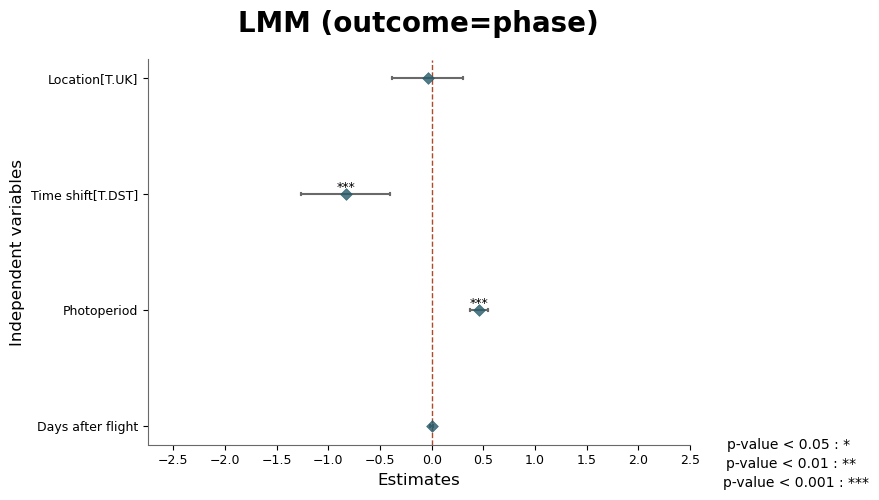

In [278]:
# initialize the matplotlib figure
plt.figure(figsize=(7, 5))
#sns.set_theme(style="whitegrid", rc={"axes.grid": False})  # set the style of the plot and remove the grid
#sns.set_palette("Paired")  # set the color palette of the plot
plt.axvline(x=0, color='#ae492a', linewidth=1, linestyle='--')  # add a vertical line at 0

ax = sns.stripplot(x="coef", y=coef_phase.index, data=coef_phase, size=6, marker='D', linewidth=0.5, color='#265a69', edgecolor='#265a69', alpha=0.8)
# add the 0.025 and 0.975 confidence intervals as T-shaped lines
for i in range(coef_phase.shape[0]):
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.975'].iloc[i]], [i, i], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.025'].iloc[i], coef_phase['0.025'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)
    plt.plot([coef_phase['0.975'].iloc[i], coef_phase['0.975'].iloc[i]], [i - 0.01, i + 0.01], color='dimgray', linewidth=1.5)

# add the significance as *** for p-value < 0.001, ** for p-value < 0.01, * for p-value < 0.05 close to the variable name
for i in range(coef_phase.shape[0]):
    if coef_phase['p-value'].iloc[i] < 0.001:
        plt.text(coef_phase['coef'].iloc[i], i, '***', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.01:
        plt.text(coef_phase['coef'].iloc[i], i, '**', ha='center', va='bottom', fontsize=9)
    elif coef_phase['p-value'].iloc[i] < 0.06:
        plt.text(coef_phase['coef'].iloc[i], i, '*', ha='center', va='bottom', fontsize=9) 

# add a legend of the significance at the top of the plot
plt.text(1.196, -0.1, 'p-value < 0.001 : ***', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.190, -0.05, 'p-value < 0.01 : ** ', ha='center', va='center', fontsize=10, transform=ax.transAxes)
plt.text(1.189, -0.00, 'p-value < 0.05 : *  ', ha='center', va='center', fontsize=10, transform=ax.transAxes)

ax.set_title('LMM (outcome=phase)', fontsize=20, fontweight='bold', pad=20)
plt.xlim(-2.75, 2.5)
plt.gca().xaxis.set_major_locator(MultipleLocator(0.5))
ax.spines['left'].set_color('dimgray')
ax.spines['bottom'].set_color('dimgray')
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
ax.set_xlabel('Estimates', fontsize=12)
ax.set_ylabel('Independent variables', fontsize=12)  # add y-axis title
# remove spines
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)


ax.set_yticklabels(['Location[T.UK]', 'Time shift[T.DST]', 'Photoperiod', 'Days after flight'])

plt.show()

<Figure size 800x600 with 0 Axes>

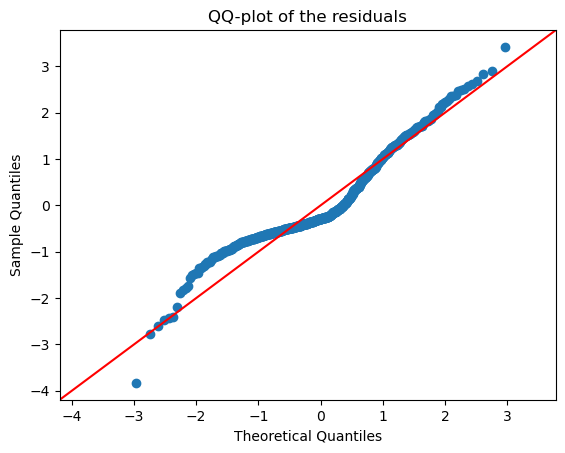

In [186]:
# QQ-plot to verify the residuals of the model
plt.figure(figsize=(8, 6))
sm.qqplot(model5b.resid, line='45')
plt.title('QQ-plot of the residuals')
plt.show()

In [187]:
residualsX = model5b.resid 
predictedX = model5b.fittedvalues

In [188]:
# Breusch-Pagan test for homoscedasticity
bp_testX = het_breuschpagan(residualsX, model5b.model.exog)

# results of the Breusch-Pagan test
bp_statX, bp_pvalX, _, _ = bp_testX
print(f'Breusch-Pagan statistic: {bp_statX}, p-value: {bp_pvalX}')
if bp_pvalX > 0.05:
    print('The residuals are homoscedastic (fail to reject H0).')
else:
    print('The residuals are heteroscedastic (reject H0).')

Breusch-Pagan statistic: 2.5351439166266108, p-value: 0.8645139533743078
The residuals are homoscedastic (fail to reject H0).


In [189]:
# Durbin-Watson test for autocorrelation
durbin_watson_testX = durbin_watson(residualsX)

print('Durbin-Watson test:', durbin_watson_testX)

Durbin-Watson test: 1.840263277472816


In [190]:
# Order the dat to fit the GEE model
df2 = df2.sort_values(by='date')

# define the structure of the GEE model(Autoregressive) to capture the temporal dependence
cov_str = sm.cov_struct.Autoregressive() # For longitudinal data: proximate data points exhibit stronger correlation than distant data points

# GEE model with random intercepts for each date
gee_model = smf.gee(
    'phase ~ C(location) + C(DST_1) + day_after_flight + photoperiod + C(location)*photoperiod + C(location)*day_after_flight',
    data=df2,
    groups=df2['flight_id'],  # to model the intra-day post-flight correlation: 
                                     # if the day after flight affects sleep in a systematic way and if observations from the same day_after_flight are more similar to each other than observations from different days
    cov_struct=cov_str,
    family=sm.families.Gaussian()
).fit()

gee_model.summary()

c:\Users\gg00642\AppData\Local\miniconda3\envs\env3\Lib\site-packages\statsmodels\genmod\cov_struct.py:796: FutureWarning: grid=True will become default in a future version
  warnings.warn(


<class 'statsmodels.iolib.summary.Summary'>
"""
                               GEE Regression Results                              
===================================================================================
Dep. Variable:                       phase   No. Observations:                  666
Model:                                 GEE   No. clusters:                       47
Method:                        Generalized   Min. cluster size:                   2
                      Estimating Equations   Max. cluster size:                  46
Family:                           Gaussian   Mean cluster size:                14.2
Dependence structure:       Autoregressive   Num. iterations:                     7
Date:                     Tue, 11 Mar 2025   Scale:                           1.090
Covariance type:                    robust   Time:                         11:11:12
======================================================================================================
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -3.7815      0.503     -7.519      0.000      -4.767      -2.796
C(location)[T.UK]                     -0.5147      0.644     -0.799      0.424      -1.777       0.748
C(DST_1)[T.1]                         -0.7298      0.124     -5.871      0.000      -0.973      -0.486
day_after_flight                      -0.0014      0.008     -0.170      0.865      -0.018       0.015
C(location)[T.UK]:day_after_flight    -0.0146      0.018     -0.803      0.422      -0.050       0.021
photoperiod                            0.4075      0.038     10.656      0.000       0.333       0.482
C(location)[T.UK]:photoperiod          0.0528      0.050      1.062      0.288      -0.045       0.150
==============================================================================
Skew:                          1.1416   Kurtosis:                       2.7033
Centered skew:                 0.5513   Centered kurtosis:              1.1630
==============================================================================
"""

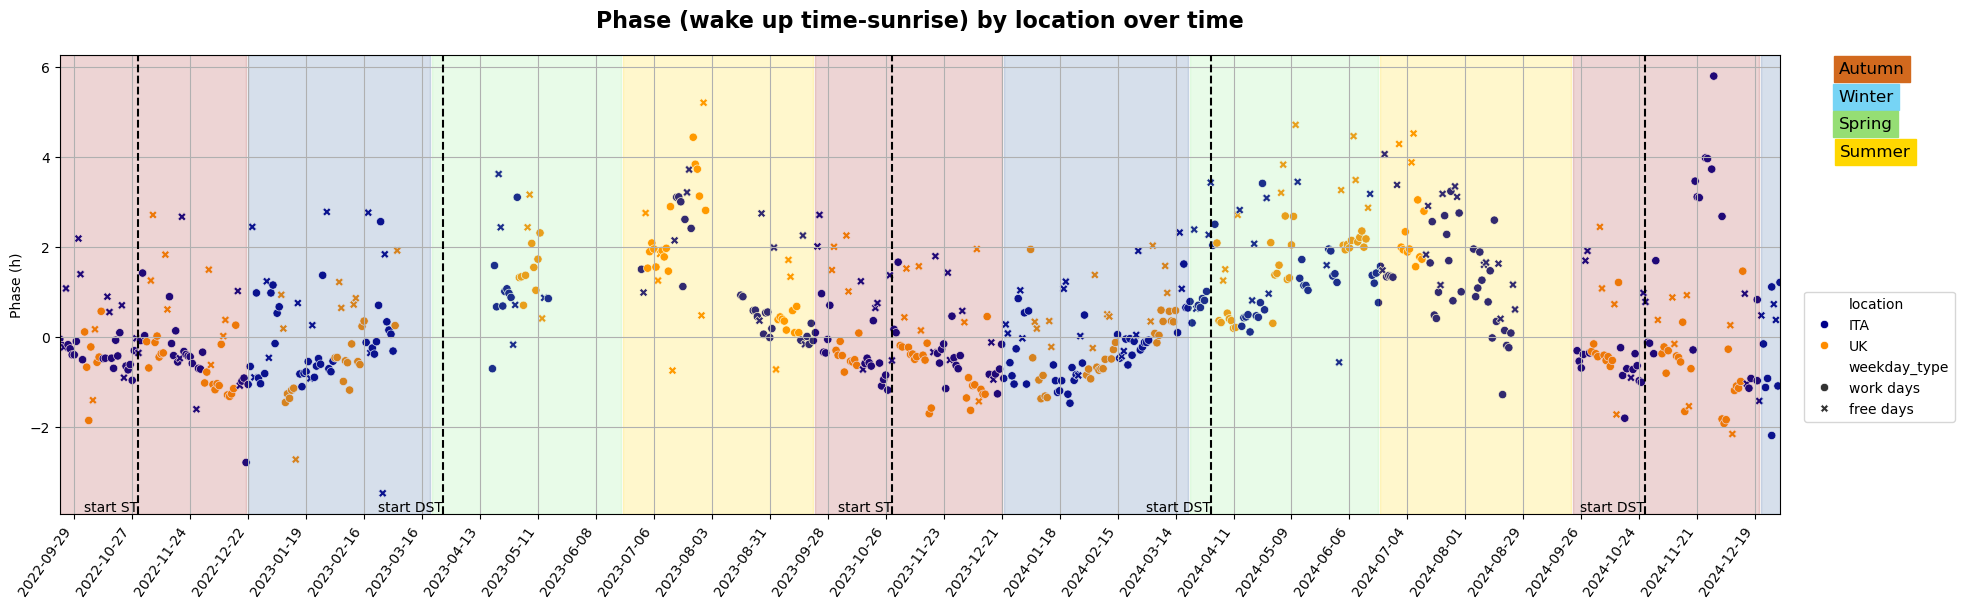

In [259]:
plt.figure(figsize=(18, 6))
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'])
plt.title('Phase (wake up time-sunrise) by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Phase (h)')
plt.xlabel('')
plt.grid(True)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.xlim(df['date'].min(), df['date'].max())
plt.gca().xaxis.set_major_locator(MultipleLocator(28)) #get the current axis = gca
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 0.5)) 

# vertical bar to indicate the start of the DST and the start of the ST 
plt.axvline(x=pd.to_datetime('2022-10-30'), color='black', linestyle='--')
plt.text(pd.to_datetime('2022-10-30'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-10-29'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-10-29'), plt.ylim()[0], 'start ST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2023-03-26'), color='black', linestyle='--')
plt.text(pd.to_datetime('2023-03-26'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-03-31'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-03-31'), plt.ylim()[0], 'start DST', ha='right', va='bottom')
plt.axvline(x=pd.to_datetime('2024-10-27'), color='black', linestyle='--')
plt.text(pd.to_datetime('2024-10-27'), plt.ylim()[0], 'start DST', ha='right', va='bottom')

# define seasons
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]

# apply the background color for each season
for start, end, color in seasons:
    plt.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

plt.annotate('Summer', xy=(1.0555, 0.79), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='gold')
plt.annotate('Autumn', xy=(1.0535, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='chocolate')
plt.annotate('Winter', xy=(1.05, 0.91), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#76d4f5')
plt.annotate('Spring', xy=(1.0499, 0.85), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor='#95de74')

plt.show()

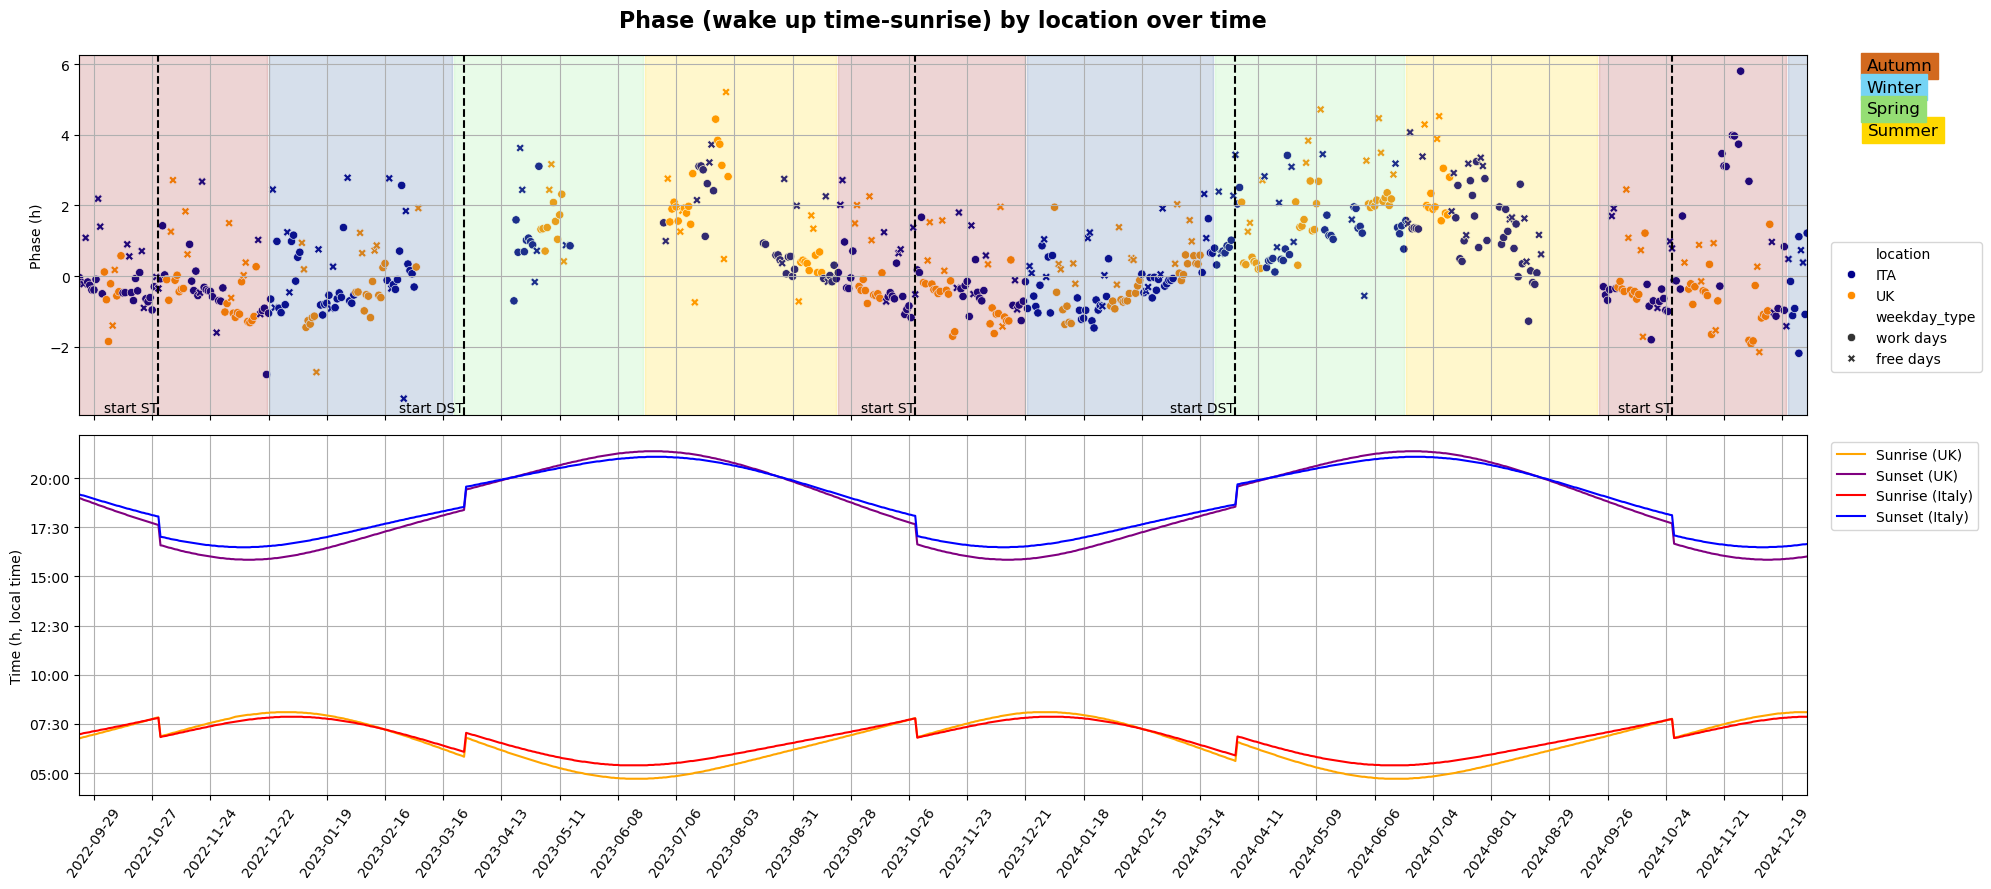

In [192]:
# Create a figure with two subplots (one above the other) with adjusted height ratios
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 9), sharex=True, gridspec_kw={'height_ratios': [5, 5]})

# Plot the phase by location over time in the top subplot
sns.scatterplot(x='date', y='phase', hue='location', style='weekday_type', data=df2, palette=['darkblue', 'darkorange'], ax=ax1)
ax1.set_title('Phase (wake up time-sunrise) by location over time', fontsize=16, fontweight='bold', loc='center', pad=20)
ax1.set_ylabel('Phase (h)')
ax1.set_xlabel('')
ax1.legend()
ax1.grid(True)
ax1.tick_params(axis='x', rotation=55)
ax1.set_xlim(df2['date'].min(), df2['date'].max())
ax1.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax1.legend(loc='upper left', bbox_to_anchor=(1.01, 0.5))

# Add vertical bars to indicate the start of DST and ST
dst_st_dates = [
    ('2022-10-30', 'start ST'),
    ('2023-10-29', 'start ST'),
    ('2023-03-26', 'start DST'),
    ('2024-03-31', 'start DST'),
    ('2024-10-27', 'start ST')
]
for date, label in dst_st_dates:
    ax1.axvline(x=pd.to_datetime(date), color='black', linestyle='--')
    ax1.text(pd.to_datetime(date), ax1.get_ylim()[0], label, ha='right', va='bottom')

# Define seasons and apply background color for each season
seasons = [
    ('2022-09-22', '2022-12-21', 'brown'),  # Autumn
    ('2022-12-22', '2023-03-20', '#335f9e'),  # Winter
    ('2023-03-21', '2023-06-20', 'lightgreen'), # Spring
    ('2023-06-21', '2023-09-21', 'gold'),     # Summer
    ('2023-09-22', '2023-12-21', 'brown'),  # Autumn
    ('2023-12-22', '2024-03-20', '#335f9e'),  # Winter
    ('2024-03-21', '2024-06-20', 'lightgreen'), # Spring
    ('2024-06-21', '2024-09-21', 'gold'),     # Summer
    ('2024-09-22', '2024-12-21', 'brown'),  # Autumn
    ('2024-12-22', '2025-03-20', '#335f9e'),  # Winter
]
for start, end, color in seasons:
    ax1.axvspan(pd.to_datetime(start), pd.to_datetime(end), color=color, alpha=0.2)

# Annotate the seasons
season_annotations = [
    ('Summer', 1.0555, 0.79, 'gold'),
    ('Autumn', 1.0535, 0.97, 'chocolate'),
    ('Winter', 1.05, 0.91, '#76d4f5'),
    ('Spring', 1.0499, 0.85, '#95de74')
]
for label, x, y, color in season_annotations:
    ax1.annotate(label, xy=(x, y), xycoords='axes fraction', ha='center', va='center', fontsize=12, backgroundcolor=color)

# Plot the sunrise and sunset times in the bottom subplot
sns.lineplot(x='date', y='sunrise (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (UK)', color='orange')
sns.lineplot(x='date', y='sunset (uk), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (UK)', color='purple')
sns.lineplot(x='date', y='sunrise (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunrise (Italy)', color='red')
sns.lineplot(x='date', y='sunset (ita), hours_adjust', data=df_daylight1, ax=ax2, label='Sunset (Italy)', color='blue')

ax2.set_ylabel('Time (h, local time)')
ax2.set_xlabel('')
# Format y-axis to hh:mm
ax2.yaxis.set_major_formatter(FuncFormatter(hours_to_hhmm))
ax2.grid(True)
ax2.tick_params(axis='x', rotation=55)
ax2.set_xlim(df2['date'].min(), df2['date'].max())
ax2.xaxis.set_major_locator(MultipleLocator(28))  # Set the x-axis major locator

#  set the legend outside the plot
ax2.legend(loc='upper left', bbox_to_anchor=(1.01, 1))

plt.tight_layout()
plt.show()


Wake After Sleep Onset

In [193]:
# drop the nan values in the waso_min column
#df_waso_clean = df.dropna(subset=['waso'])
#df_waso_clean_x = df_flight.dropna(subset=['waso'])

In [194]:
model1a = smf.mixedlm('waso ~ day_after_flight', df3, groups=df3['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1a.summary())

           Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  waso      
No. Observations:  661      Method:              REML      
No. Groups:        47       Scale:               855.9940  
Min. group size:   2        Log-Likelihood:      -3187.6506
Max. group size:   45       Converged:           Yes       
Mean group size:   14.1                                    
-----------------------------------------------------------
                 Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------
Intercept        50.610    2.389 21.184 0.000 45.927 55.293
day_after_flight  0.105    0.196  0.535 0.593 -0.279  0.488
Group Var        84.592    1.131                           



In [195]:
model2 = smf.mixedlm('waso ~ day_after_flight + C(location) + C(location)*day_after_flight', df3, groups=df3['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        waso      
No. Observations:        661            Method:                    REML      
No. Groups:              47             Scale:                     849.8460  
Min. group size:         2              Log-Likelihood:            -3175.4641
Max. group size:         45             Converged:                 Yes       
Mean group size:         14.1                                                
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                          41.950    2.874 14.596 0.000 36.317 47.583
C(location)[T.UK]                  21.446    4.792  4.476 0.000 12.054 30.838
day_after_flight                    0.423    0.211  2.001 0.045  0.009  0.837
C(loca

In [196]:
shapiro_test_waso = stats.shapiro(df3_flight_uk['waso'])

shapiro_test_waso

ShapiroResult(statistic=0.9869756984551192, pvalue=0.5460153725528771)

In [197]:
ttest_waso_days_uk = stats.ttest_ind(df3_flight_uk[df3_flight_uk['day_after_flight_group'] == '0']['waso'],
                                        df3_flight_uk[df3_flight_uk['day_after_flight_group'] == '1']['waso'])

ttest_waso_days_uk

TtestResult(statistic=-2.7055980814490255, pvalue=0.008254858442118436, df=84.0)

In [198]:
# mean and std by day_after_flight_group 
df3_grouped_flight_uk = df3_flight_uk.groupby(['day_after_flight_group']).agg({'waso': ['mean', 'std']})
df3_grouped_flight_uk


waso           
                             mean        std
day_after_flight_group                      
0                       53.666667  25.204617
1                       70.048780  30.869039

In [199]:
shapiro_test_waso = stats.shapiro(df3_flight_ita['phase'])

shapiro_test_waso

ShapiroResult(statistic=0.955567539606057, pvalue=0.00329370317619469)

In [200]:
utest_waso_days_ita = stats.mannwhitneyu(df3_flight_ita[df3_flight_ita['day_after_flight_group'] == '0']['waso'],
                                        df3_flight_ita[df3_flight_ita['day_after_flight_group'] == '1']['waso'])

utest_waso_days_ita

MannwhitneyuResult(statistic=991.5, pvalue=0.6088304586209559)

In [201]:
df3_grouped_flight_ita = df3_flight_ita.groupby(['day_after_flight_group']).agg({'waso': ['mean', 'std']})
df3_grouped_flight_ita

waso           
                             mean        std
day_after_flight_group                      
0                       45.659574  29.635669
1                       47.777778  27.662650

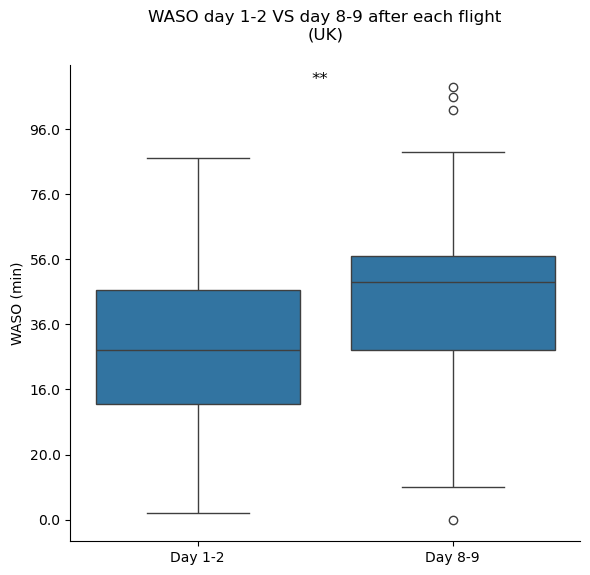

In [202]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='waso', data=df_flight_uk)
plt.title('WASO day 1-2 VS day 8-9 after each flight\n(UK)\n')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('WASO (min)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 26.8)
plt.annotate('**', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

_Sleep duration_

In [203]:
model1 = smf.mixedlm('sleep_duration ~ day_after_flight', df1, groups=df1['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model1.summary())

           Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: sleep_duration
No. Observations: 666     Method:             REML          
No. Groups:       47      Scale:              1.9272        
Min. group size:  2       Log-Likelihood:     -1186.0665    
Max. group size:  46      Converged:          Yes           
Mean group size:  14.2                                      
------------------------------------------------------------
                  Coef.  Std.Err.   z    P>|z| [0.025 0.975]
------------------------------------------------------------
Intercept          8.885    0.111 80.111 0.000  8.668  9.102
day_after_flight  -0.004    0.009 -0.392 0.695 -0.022  0.014
Group Var          0.166    0.049                           



In [204]:
model2 = smf.mixedlm('sleep_duration ~ day_after_flight + location + location*day_after_flight', df1, groups=df1['flight_id']).fit(method='powell', maxiter=1000) # different optimization methods to provide better convergence: common methods include 'lbfgs', 'cg', 'powell', and 'bfgs'.

print(model2.summary())

                  Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     sleep_duration
No. Observations:       666         Method:                 REML          
No. Groups:             47          Scale:                  1.9166        
Min. group size:        2           Log-Likelihood:         -1188.2797    
Max. group size:        46          Converged:              Yes           
Mean group size:        14.2                                              
--------------------------------------------------------------------------
                                Coef.  Std.Err.   z    P>|z| [0.025 0.975]
--------------------------------------------------------------------------
Intercept                        8.907    0.149 59.948 0.000  8.616  9.198
location[T.UK]                  -0.200    0.242 -0.828 0.408 -0.675  0.274
day_after_flight                -0.010    0.010 -0.992 0.321 -0.030  0.010
location[T.UK]:day_after_flight  0.039    0.

In [205]:
shapiro_test_duration = stats.shapiro(df1_flight_uk['sleep_duration'])

shapiro_test_duration

ShapiroResult(statistic=0.9678324012425327, pvalue=0.030500472136631363)

In [206]:
ttest_duration_days_uk = stats.ttest_ind(df1_flight_uk[df1_flight_uk['day_after_flight_group'] == '0']['sleep_duration'],
                                        df1_flight_uk[df1_flight_uk['day_after_flight_group'] == '1']['sleep_duration'])

ttest_duration_days_uk

TtestResult(statistic=-2.2903243897663965, pvalue=0.024508697705957264, df=84.0)

In [207]:
# mean and std by day_after_flight_group 
df1_grouped_flight_uk = df1_flight_uk.groupby(['day_after_flight_group']).agg({'sleep_duration': ['mean', 'std']})
df1_grouped_flight_uk


sleep_duration          
                                 mean       std
day_after_flight_group                         
0                            8.378333  1.513339
1                            9.082520  1.318978

In [208]:
shapiro_test_duration = stats.shapiro(df1_flight_ita['sleep_duration'])

shapiro_test_duration

ShapiroResult(statistic=0.9693131119358877, pvalue=0.02738906655060135)

In [209]:
utest_midsleep_days_ita = stats.mannwhitneyu(df_flight_ita[df_flight_ita['day_after_flight_group'] == '0']['midsleep_h'],
                                        df_flight_ita[df_flight_ita['day_after_flight_group'] == '1']['midsleep_h'])

utest_midsleep_days_ita

MannwhitneyuResult(statistic=1074.0, pvalue=0.35750464182577646)

In [210]:
df_grouped_flight_ita = df_flight_ita.groupby(['day_after_flight_group']).agg({'midsleep_h': ['mean', 'std']})
df_grouped_flight_ita

midsleep_h          
                             mean       std
day_after_flight_group                     
0                       27.048050  0.835002
1                       26.915854  0.944040

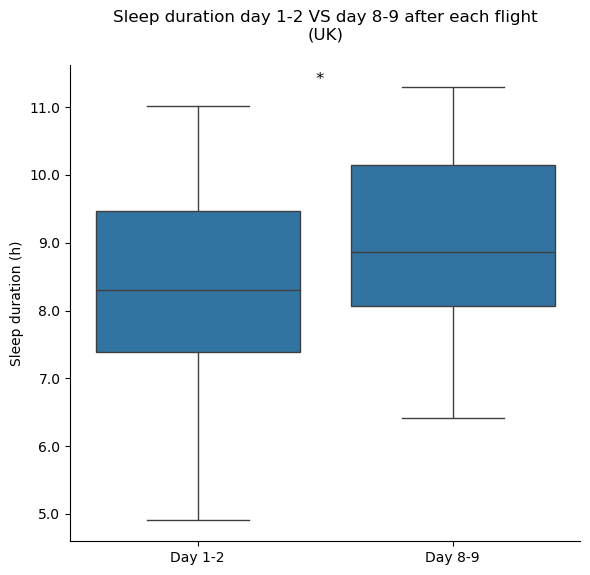

In [258]:
# plot the sleep onset by day after flight
plt.figure(figsize=(6, 6))
sns.boxplot(x='day_after_flight_group', y='sleep_duration', data=df_flight_uk)
plt.title('Sleep duration day 1-2 VS day 8-9 after each flight\n(UK)\n')
plt.suptitle('')  # add space between the title and the plot
plt.ylabel('Sleep duration (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.gca().spines['bottom'].set_color('black')
plt.gca().spines['left'].set_color('black')
sns.despine()
plt.grid(False)
#plt.ylim(18.5, 26.8)
plt.annotate('*', xy=(0.49, 0.97), xycoords='axes fraction', ha='center', va='center', fontsize=12)
plt.tight_layout()
plt.xticks([0, 1], ['Day 1-2', 'Day 8-9'])

plt.show()

_Analysis of the subset: January 2023-2024-2025_

In [212]:
df_2025 = pd.read_excel(fpath + '\\10.0_database_variables.xlsx', sheet_name='v2database2022_2025')

In [213]:
# extract january data
df_january23 = df[(df['date'] >= '2023-01-01') & (df['date'] <= '2023-01-31')]
df_january24 = df[(df['date'] >= '2024-01-01') & (df['date'] <= '2024-01-31')]
df_january25 = df_2025[(df_2025['date'] >= '2025-01-01') & (df_2025['date'] <= '2025-01-31')]

In [214]:
df_january23 = df_january23.drop(['sleep_duration_free_days', 'sleep_duration_work_days', 'sleep_end_decimal_plot', 'sleep_end_decimal_UTC_plot', 'photoperiod_tertile', 'week_of_year', 'season'], axis=1)  
df_january24 = df_january24.drop(['sleep_duration_free_days', 'sleep_duration_work_days', 'sleep_end_decimal_plot', 'sleep_end_decimal_UTC_plot', 'photoperiod_tertile', 'week_of_year', 'season'], axis=1)

In [215]:
# rename the location column as 0=ITA, 1=UK
df_january25['location'] = df_january25['location'].map({0: 'ITA', 1: 'UK'})

# rename the weekday column as 0=work days, 1=free days
df_january25['weekday_type'] = df_january25['weekday_type'].map({0: 'work days', 1: 'free days'})

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\1748530833.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_january25['location'] = df_january25['location'].map({0: 'ITA', 1: 'UK'})
C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\1748530833.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_january25['weekday_type'] = df_january25['weekday_type'].map({0: 'work days', 1: 'free days'})


In [216]:
# new variable 'photoperiod' based on the location
# if column 'location' = 1 take the value from 'photoperiod (h, UK)' 
# if column 'location' = 0 then photoperiod (h, ITA)'
df_january25['photoperiod'] = np.where(df_january25['location'] == 'UK', df_january25['photoperiod (h, UK)'], df_january25['photoperiod (h, ITA)'])

C:\Users\gg00642\AppData\Local\Temp\ipykernel_17824\2692187123.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_january25['photoperiod'] = np.where(df_january25['location'] == 'UK', df_january25['photoperiod (h, UK)'], df_january25['photoperiod (h, ITA)'])


In [217]:
# concatenate the two dataframes
df_january = pd.concat([df_january23, df_january24, df_january25], ignore_index=True)

In [218]:
# add a column if date 2025=1 and 2024=0
df_january['year'] = df_january['date'].dt.year

In [219]:
# if location=1 , delete row
df_january_ita = df_january[df_january['location'] != 'UK']

In [220]:
df_january.groupby('year').describe()

#print as a table
df_january.groupby('year').describe().T

year                                           2023  \
start_datetime count                             27   
               mean   2023-01-14 19:33:13.333332992   
               min              2022-12-31 23:22:00   
               25%              2023-01-07 11:59:30   
               50%              2023-01-14 21:53:00   
...                                             ...   
photoperiod    25%                         8.533333   
               50%                              9.1   
               75%                            9.325   
               max                              9.7   
               std                         0.529843   

year                                           2024  \
start_datetime count                             31   
               mean   2024-01-15 22:20:32.903225600   
               min              2024-01-01 00:17:00   
               25%              2024-01-08 12:02:00   
               50%              2024-01-15 20:33:00   
...                                             ...   
photoperiod    25%                              8.2   
               50%                              9.1   
               75%                         9.358333   
               max                         9.666667   
               std                         0.596088   

year                                           2025  
start_datetime count                             29  
               mean   2025-01-16 21:12:35.172414208  
               min              2025-01-01 23:20:00  
               25%              2025-01-09 19:39:00  
               50%              2025-01-16 19:37:00  
...                                             ...  
photoperiod    25%                             8.95  
               50%                             9.15  
               75%                         9.383333  
               max                         9.666667  
               std                         0.266387  

[216 rows x 3 columns]

In [221]:
# count the day for jan 2023, 2024, 2025
df_january['year'].value_counts()

year
2024    31
2025    29
2023    27
Name: count, dtype: int64

In [222]:
anova_jan_midsleep = ols('midsleep_h ~ C(year)', data=df_january).fit() # generate and fit the regression model
anovaresults_jan_midsleep = sm.stats.anova_lm(anova_jan_midsleep, typ=3)

In [223]:
print('ANOVA Result for midsleep:')
print(anovaresults_jan_midsleep)

ANOVA Result for midsleep:
                 sum_sq    df             F         PR(>F)
Intercept  19506.323259   1.0  21725.669109  3.433959e-103
C(year)        6.247005   2.0      3.478881   3.535573e-02
Residual      75.419134  84.0           NaN            NaN


In [224]:
# mean and std of midsleep by year
midsleep_jan_year = df_january.groupby(['year']).agg({'midsleep_h': ['mean', 'std']})

print(midsleep_jan_year)

     midsleep_h          
           mean       std
year                     
2023  26.878549  0.919614
2024  26.886962  0.851668
2025  26.314655  1.063536


In [225]:
posthoc_midsleep = pairwise_tukeyhsd(df_january['midsleep_h'], df_january['year'])
print(posthoc_midsleep)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
  2023   2024   0.0084 0.9994 -0.5867 0.6035  False
  2023   2025  -0.5639 0.0727 -1.1685 0.0407  False
  2024   2025  -0.5723 0.0561 -1.1564 0.0118  False
---------------------------------------------------


In [226]:
anova_jan_sleepduration = ols('sleep_duration ~ C(year)', data=df_january).fit() # generate and fit the regression model
anovaresults_jan_sleepduration = sm.stats.anova_lm(anova_jan_sleepduration, typ=3)

In [227]:
print('ANOVA Result for sleep duration:')
print(anovaresults_jan_sleepduration)

ANOVA Result for sleep duration:
                sum_sq    df            F        PR(>F)
Intercept  2340.658151   1.0  1405.610701  3.173099e-54
C(year)       8.520952   2.0     2.558499  8.344247e-02
Residual    139.878904  84.0          NaN           NaN


In [228]:
# sleep onset kuskal wallis test
kw_jan_sleep_onset = stats.kruskal(df_january[df_january['year'] == 2023]['sleep_start_decimal'], df_january[df_january['year'] == 2024]['sleep_start_decimal'], df_january[df_january['year'] == 2025]['sleep_start_decimal'])
# sleep end kuskal wallis test
kw_jan_sleep_end = stats.kruskal(df_january[df_january['year'] == 2023]['sleep_end_decimal'], df_january[df_january['year'] == 2024]['sleep_end_decimal'], df_january[df_january['year'] == 2025]['sleep_end_decimal'])
# waso kruskal wallis test
kw_jan_waso = stats.kruskal(df_january[df_january['year'] == 2023]['waso'], df_january[df_january['year'] == 2024]['waso'], df_january[df_january['year'] == 2025]['waso'])

In [229]:
# print the results
print(f"Sleep onset: {kw_jan_sleep_onset}")
print(f"Sleep offset: {kw_jan_sleep_end}")
print(f"WASO: {kw_jan_waso}")

Sleep onset: KruskalResult(statistic=0.30232224984876543, pvalue=0.8597091669245357)
Sleep offset: KruskalResult(statistic=24.579241070225468, pvalue=4.599235172629617e-06)
WASO: KruskalResult(statistic=2.927964965754608, pvalue=0.23131323695318978)


In [230]:
posthoc_sleepoffset = pairwise_tukeyhsd(df_january['sleep_end_decimal'], df_january['year'])

print(posthoc_sleepoffset)

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  2023   2024  -0.1063 0.8815 -0.6358  0.4233  False
  2023   2025   -0.942 0.0002   -1.48  -0.404   True
  2024   2025  -0.8357 0.0007 -1.3554 -0.3161   True
----------------------------------------------------


In [231]:
# mean and std of slep offset by year
sleepoffset_jan_year = df_january.groupby(['year']).agg({'sleep_end_decimal': ['mean', 'std']})

print(sleepoffset_jan_year)

     sleep_end_decimal          
                  mean       std
year                            
2023         31.533951  0.848204
2024         31.427688  0.914258
2025         30.591954  0.754163


In [232]:
anova_jan_midsleep_ita = ols('midsleep_h ~ C(year)', data=df_january_ita).fit() # generate and fit the regression model
anovaresults_jan_midsleep_ita = sm.stats.anova_lm(anova_jan_midsleep_ita, typ=3)

In [233]:
print('ANOVA Result for midsleep:')
print(anovaresults_jan_midsleep_ita)

ANOVA Result for midsleep:
                 sum_sq    df             F        PR(>F)
Intercept  14529.868170   1.0  16799.528491  3.448649e-80
C(year)        5.521969   2.0      3.192268  4.759368e-02
Residual      56.218330  65.0           NaN           NaN


In [260]:
# mean and std of midsleep by year
midsleep_jan_ita_year = df_january_ita.groupby(['year']).agg({'midsleep_h': ['mean', 'std']})

print(midsleep_jan_ita_year)

     midsleep_h          
           mean       std
year                     
2023  26.953542  0.772777
2024  26.800000  0.856374
2025  26.314655  1.063536


In [234]:
anova_jan_sleepduration_ita = ols('sleep_duration ~ C(year)', data=df_january_ita).fit() # generate and fit the regression model
anovaresults_jan_sleepduration_ita = sm.stats.anova_lm(anova_jan_sleepduration_ita, typ=3)

In [235]:
print('ANOVA Result for sleep duration:')
print(anovaresults_jan_sleepduration_ita)

ANOVA Result for sleep duration:
                sum_sq    df            F        PR(>F)
Intercept  1738.024753   1.0  1048.145019  8.188974e-42
C(year)       7.110702   2.0     2.144114  1.253868e-01
Residual    107.782422  65.0          NaN           NaN


In [236]:
# sleep onset kuskal wallis test
kw_jan_sleep_onset_ita = stats.kruskal(df_january_ita[df_january_ita['year'] == 2023]['sleep_start_decimal'], df_january_ita[df_january_ita['year'] == 2024]['sleep_start_decimal'], df_january_ita[df_january_ita['year'] == 2025]['sleep_start_decimal'])
# sleep end kuskal wallis test
kw_jan_sleep_end_ita = stats.kruskal(df_january_ita[df_january_ita['year'] == 2023]['sleep_end_decimal'], df_january_ita[df_january_ita['year'] == 2024]['sleep_end_decimal'], df_january_ita[df_january_ita['year'] == 2025]['sleep_end_decimal'])
# waso kruskal wallis test
kw_jan_waso_ita = stats.kruskal(df_january_ita[df_january_ita['year'] == 2023]['waso'], df_january_ita[df_january_ita['year'] == 2024]['waso'], df_january_ita[df_january_ita['year'] == 2025]['waso'])

In [237]:
# print the results
print(f"Sleep onset: {kw_jan_sleep_onset_ita}")
print(f"Sleep offset: {kw_jan_sleep_end_ita}")
print(f"WASO: {kw_jan_waso_ita}")

Sleep onset: KruskalResult(statistic=0.23996782011525836, pvalue=0.8869347073306781)
Sleep offset: KruskalResult(statistic=21.77311895310154, pvalue=1.870799703571509e-05)
WASO: KruskalResult(statistic=1.211554744030638, pvalue=0.5456500886177793)


In [261]:
# mean and std of midsleep by year
offset_jan_ita_year = df_january_ita.groupby(['year']).agg({'sleep_end_decimal': ['mean', 'std']})

print(offset_jan_ita_year)

     sleep_end_decimal          
                  mean       std
year                            
2023         31.614583  0.822259
2024         31.284211  0.849187
2025         30.591954  0.754163


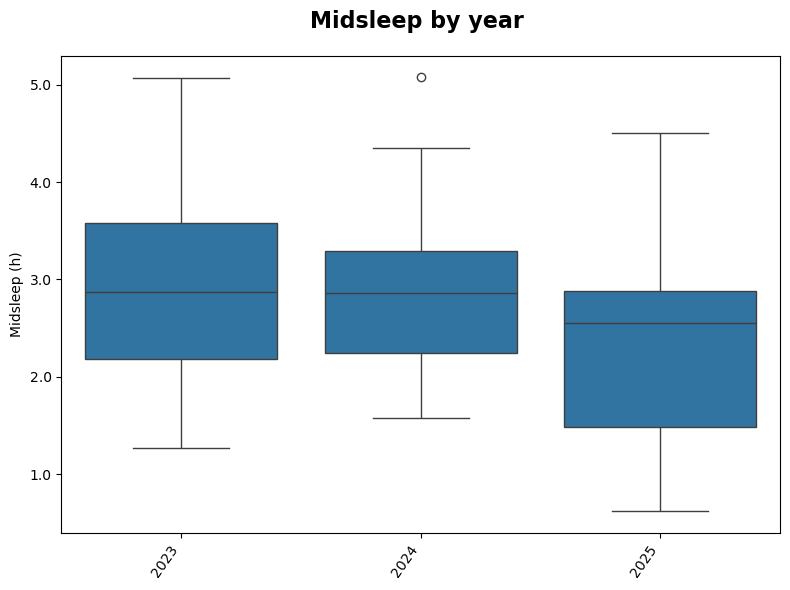

In [238]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='midsleep_h', data=df_january)
plt.title('Midsleep by year ', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Midsleep (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.grid(False)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.show()

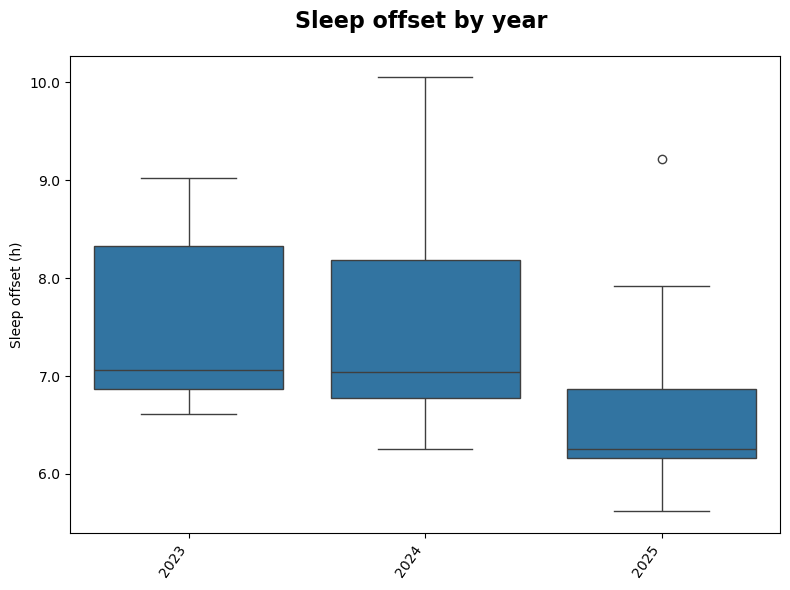

In [239]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='sleep_end_decimal', data=df_january)
plt.title('Sleep offset by year ', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Sleep offset (h)')
plt.xlabel('')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: (x - 24) if x > 24 else x))
plt.grid(False)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.show()

In [240]:
# one way anova with the photoperiod between 2023, 2024, 2025
anova_jan_photoperiod = stats.f_oneway(df_january_ita[df_january_ita['year'] == 2023]['photoperiod'], df_january_ita[df_january_ita['year'] == 2024]['photoperiod'], df_january_ita[df_january_ita['year'] == 2025]['photoperiod'])

print(anova_jan_photoperiod)

F_onewayResult(statistic=0.7221709987152967, pvalue=0.489552114279429)


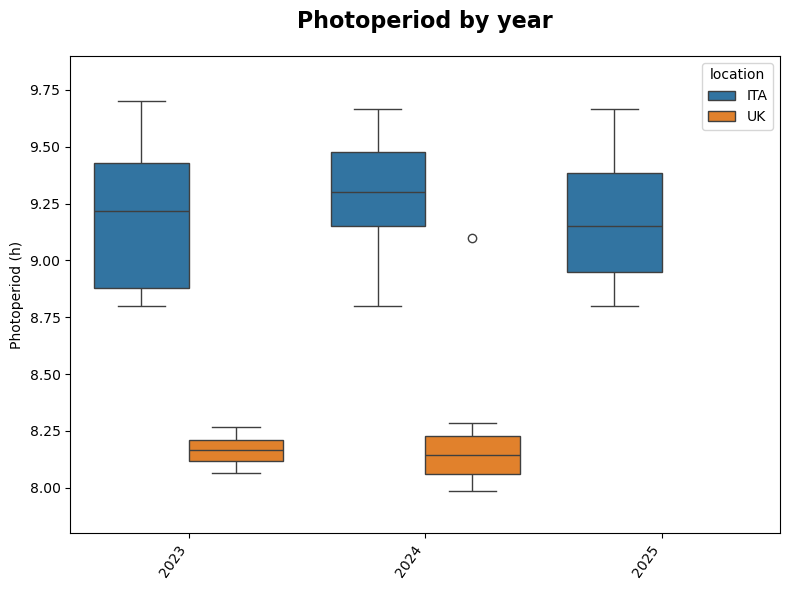

In [241]:
#plot the photoperiod across the years
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='photoperiod', data=df_january, hue='location')
plt.title('Photoperiod by year', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Photoperiod (h)')
plt.xlabel('')
plt.grid(False)
plt.xticks(rotation=55, ha='right')
plt.ylim(7.8, 9.9)
plt.tight_layout()
plt.show()

In [242]:
# Fit the factorial ANOVA model
model_jan1 = ols('sleep_end_decimal ~ year * weekday_type', data=df_january_ita).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model_jan1, typ=2)

print(anova_results)

                      sum_sq    df          F    PR(>F)
weekday_type        2.704801   1.0   4.388496  0.040145
year               13.825852   1.0  22.432225  0.000013
year:weekday_type   0.044994   1.0   0.073002  0.787884
Residual           39.445686  64.0        NaN       NaN


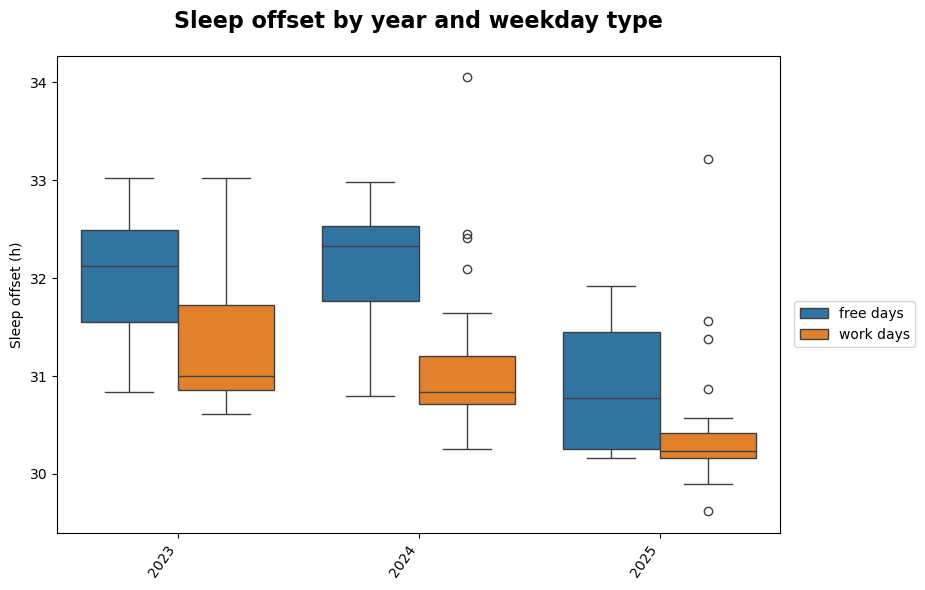

In [243]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='year', y='sleep_end_decimal', data=df_january, hue='weekday_type')
plt.title('Sleep offset by year and weekday type', fontsize=16, fontweight='bold', loc='center', pad=20)
plt.ylabel('Sleep offset (h)')
plt.xlabel('')
plt.grid(False)
plt.xticks(rotation=55, ha='right')
plt.tight_layout()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 0.5))
plt.show()

In [244]:
# Fit the factorial ANOVA model
model_jan2 = ols('midsleep_h ~ year * weekday_type', data=df_january).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model_jan2, typ=2)

print(anova_results)

                      sum_sq    df         F    PR(>F)
weekday_type        5.953850   1.0  6.952528  0.009989
year                5.081987   1.0  5.934421  0.016988
year:weekday_type   0.069141   1.0  0.080738  0.777007
Residual           71.077681  83.0       NaN       NaN
